**Examples from Plant Operating Reports & Case Studies**

| Mine/Project     | CN Dosage (kg/t) | CN Conc (ppm) | Ore Type       | Notes            |
| ---------------- | ---------------- | ------------- | -------------- | ---------------- |
| Lihir            | 0.6–0.8          | \~400         | Sulphide       | High T° leach    |
| Tasiast          | 0.7–1.0          | 250–400       | Mixed          | Ag-rich          |
| Tanami           | 0.5–0.7          | 200–300       | Sulphide       | CIL circuit      |
| KCGM (Super Pit) | 0.3–0.5          | 150–250       | Oxide/Sulphide | CN recirculation |
| Hemlo            | 0.5–0.9          | 200–350       | Sulphide       | Gold-silver feed |


## 📚 Step 0: Import libraries

Load core libraries for data handling, modelling, and visualisation.

In [1]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import plotly.express as px
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, root_mean_squared_error)
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.ensemble import (GradientBoostingRegressor, StackingRegressor,
                              HistGradientBoostingRegressor, RandomForestRegressor)
from sklearn.linear_model import ElasticNet, QuantileRegressor, ElasticNetCV, Ridge
from sklearn.exceptions import ConvergenceWarning
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.tree import DecisionTreeRegressor
from sklearn.cluster import KMeans
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor
import shap
from scipy.stats import linregress
from scipy.optimize import minimize, curve_fit, differential_evolution
from tqdm import tqdm
from datetime import timedelta
from itertools import product
import joblib
import optuna
import warnings

## 📥 Step 1: Load dataset

Import the dataset and standardise column names for consistency.

In [2]:
# Load dataset
df = pd.read_csv('site_leaching_data.csv')
df_jun = pd.read_csv('site_leaching_data_jun_25.csv')
df_jan = pd.read_csv('site_leaching_data_jun_25.csv')

# Ensure datetime is parsed
df["Date"] = pd.to_datetime(df["Date"])
df_jan["Date"] = pd.to_datetime(df_jan["Date"])
df_jun["Date"] = pd.to_datetime(df_jun["Date"])

# Create subsets of the latest data
df_jan = df_jan[df_jan["Date"] >= "2025-01-01"]
df_jun = df_jun[df_jun["Date"] >= "2025-05-01"]

## ⚙️ Step 2: Define constants

Set plant configuration, material properties, modelling parameters, and economic assumptions.

In [3]:
# Plant configuration constants
PRELEACH_TANKS = 2           	# number of pre-leaching tanks
CIL_TANKS = 9                 	# number of CIL tanks
PRELEACH_TANK_VOLUE = 1000.0  	# volume of the pre-leaching tanks in m^3
CIL_TANK_VOLUME = 250.0        	# volume of the CIL tanks in m^3
CARBON_CONCENTRATION = 8.0      # concentration of carbon in the CIL tanks in g/L
carbon_mass_g = CARBON_CONCENTRATION * CIL_TANK_VOLUME * 1000
carbon_mass_t = carbon_mass_g / 1e6 # convert to tonnes

# Material characteristics
SOLIDS_DENSITY = 2.70
SOLUTION_DENSITY = 1.10

# Constants for the training & modeling process
random_seed = 13				# random seed for reproducibility
test_sample_size = 0.2			# proportion of data to use for testing
bin_precision = 1				# precision for binning continuous variables

# Cyanide leaching parameters
min_cn_hist = 100 			    # min. CN in ppm for cleansing historicals
max_cn_hist = 1200 				# max. CN in ppm for cleansing historicals

min_cn_thresh = 50	 			# min. CN threshold in ppm for modelling
max_cn_thresh = 600 			# max. CN threshold in ppm for modelling

min_do_thresh = 13.0 			# min DO in ppm for modelling
max_do_thresh = 17.0 			# max DO in ppm for modelling
do_smoothing_window = 45		# smoothing window in days for DO data

# Set CN bounds
cn_lower_bound = 200  			# lower bound for cyanide concentration in ppm in PL 01
cn_upper_bound = 500  			# upper bound for cyanide concentration in ppm in PL 01
penalty_threshold = 550  		# where overdose penalty kicks in
penalty_weight = 0.5     		# USD per excess ppm * t

do_lower_bound = 13.0  			# lower bound for dissolved oxygen in ppm in PL 01
do_upper_bound = 17.0  			# upper bound for dissolved oxygen in ppm in PL 01

# Feed charateristics
ultra_fine_sizing = 50	 		# midpoint for < 75 µm sizing
fine_sizing = 112.5				# midpoint for > 75 µm sizing
coarse_sizing = 175 			# midpoint for > 150 µm sizing

# Performance metric thresholds (used for weekly plotting)
recovery_green = 4				# recovery value delta threshold for green zone in USD per tonne
recovery_orange = 7				# recovery value delta threshold for orange zone in USD per tonne
cn_green = 0.15					# cyanide concentration threshold for green zone as delta % to optimal
cn_orange = 0.30				# cyanide concentration threshold for orange zone as delta % to optimal
do_green = 0.10					# dissolved oxygen concentration threshold for green zone as delta % to optimal
do_orange = 0.35				# dissolved oxygen concentration threshold for orange zone as delta % to optimal

# Economic constants
GOLD_PRICE_USD_PER_G = 89.24
NACN_PRICE_USD_PER_KG = 2.7
DO_PRICE_USD_PER_KG = 0.03 	    # USD per kg per tonne
TROY_OZ_TO_G = 31.1035
PPM_TO_KG_PER_T = 1 / 1_000_000 * 1_000  # convert ppm to kg/t
CN_PENALTY_THRESHOLD = 450      # ppm
CN_PENALTY_WEIGHT = 1.0         # USD per ppm per tonne above threshold

## Step 3: Define plotting helpers

In [4]:
# Create a scatter plot with regression line helper
def scatter_with_regression(x, y, xlabel, ylabel, title, fig_size=(10, 6), title_fontsize=16,
                            alpha=0.5, reg_color='red'):
    """
    Create a scatter plot with a regression line.
    Parameters:
    - x: Column name for x-axis data.
    - y: Column name for y-axis data.
    - xlabel: Label for x-axis.
    - ylabel: Label for y-axis.
    - title: Title of the plot.
    - fig_size: Size of the figure.
    - title_fontsize: Font size for the title.
    - alpha: Transparency level for the scatter points.
    - reg_color: Color of the regression line.
    """

    plt.figure(figsize=fig_size)
    sns.set_theme(style="whitegrid")
    sns.regplot(x=x, y=y, scatter_kws={'alpha':alpha}, line_kws={'color':reg_color})
    plt.title(title, fontsize=title_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(False)
    plt.show()


def scatter_with_axline(df, x, y, xlabel, ylabel, title, fig_size=(10, 6), title_fontsize=16,
                            alpha=0.5,
                            ax_loc=0, ax_color='red', ax_linestyle='--', ax_label='Zero Line'):
    """
    Create a scatter plot with an axline at a specified location.
    Parameters:
    - df: DataFrame containing the data.
    - x: Column name for x-axis data.
    - y: Column name for y-axis data.
    - xlabel: Label for x-axis.
    - ylabel: Label for y-axis.
    - title: Title of the plot.
    - fig_size: Size of the figure.
    - title_fontsize: Font size for the title.
    - alpha: Transparency level for the scatter points.
    - ax_loc: Location of the axline (default is 0).
    - ax_color: Color of the axline.
    - ax_linestyle: Style of the axline (e.g., '--', '-.', etc.).
    - ax_label: Label for the axline.
    """
    
    plt.figure(figsize=fig_size)
    sns.set_theme(style="whitegrid")
    sns.scatterplot(x=x, y=y, data=df)
    plt.axhline(ax_loc, linestyle=ax_linestyle, color=ax_color, label=ax_label)
    plt.title(title, fontsize=title_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(False)
    plt.show()


# Create a parity plot
def comparison_scatter_ideal_line(df, x_col, y_col, xlabel, ylabel, title,
                                  fig_size=(6, 6), title_fontsize=16,
                xbounds=None, ybounds=None,
                alpha=0.6, ideal_line_color='red', ideal_line_style='--'):
    """
    Create a scatter plot with an ideal line (y=x) for comparison.
    Parameters:
    - df: DataFrame containing the data.
    - x_col: Column name for x-axis data.
    - y_col: Column name for y-axis data.
    - xlabel: Label for x-axis.
    - ylabel: Label for y-axis.
    - title: Title of the plot.
    - fig_size: Size of the figure.
    - title_fontsize: Font size for the title.
    - xbounds: Optional bounds for x-axis.
    - ybounds: Optional bounds for y-axis.
    - alpha: Transparency level for the scatter points.
    - ideal_line_color: Color of the ideal line.
    - ideal_line_style: Style of the ideal line (e.g., '--', '-.', etc.).
    """

    if not xbounds: xbounds=[df[x_col].min(), df[x_col].max()]
    if not ybounds: ybounds=[df[y_col].min(), df[y_col].max()]
    plt.figure(figsize=fig_size)
    sns.set_theme(style="whitegrid")
    sns.scatterplot(x=x_col, y=y_col, data=df, alpha=alpha)
    plt.plot(xbounds, ybounds,
             color=ideal_line_color, linestyle=ideal_line_style, label='Ideal')
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title, fontsize=title_fontsize)
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()


#### **Total Gold Input (per day)**
$$Gold Feed (grams) = Milled Tonnes × Feed Grade$$

This is the total gold entering the circuit.

#### Observed Gold Outputs
| Component                     | Field                               | Notes                                              |
| ----------------------------- | ----------------------------------- | -------------------------------------------------- |
| ✅ **On Carbon**               | `Gold in Carbon (Au grams)`         | Gold adsorbed and retained on carbon               |
| ✅ **In Solution**             | `Dissolved gold (Au grams)` (sum)   | Total across all leach and CIL tanks               |
| ✅ **In Tailings**             | `Gold in Tailings (Au grams)`       | Residual dissolved or undissolved gold in tailings |
| 🔸 **Undissolved in Circuit** | `Total Undissolved Gold (Au grams)` | Includes locked or passivated gold not yet leached |

Gold Reconciliation Equation
We can now define:

$$Gold Feed (g) = Gold on Carbon + Gold in Solution + Gold in Tailings + Undissolved Gold + Unaccounted Loss$$

Compute this and see how well the totals reconcile.

Let’s do a sample row-wise check to estimate:
* Gold Feed
* Sum of the accounted outputs
* Gap (Unaccounted Loss)

### 🔄 Total Au Inventory vs. Daily Change

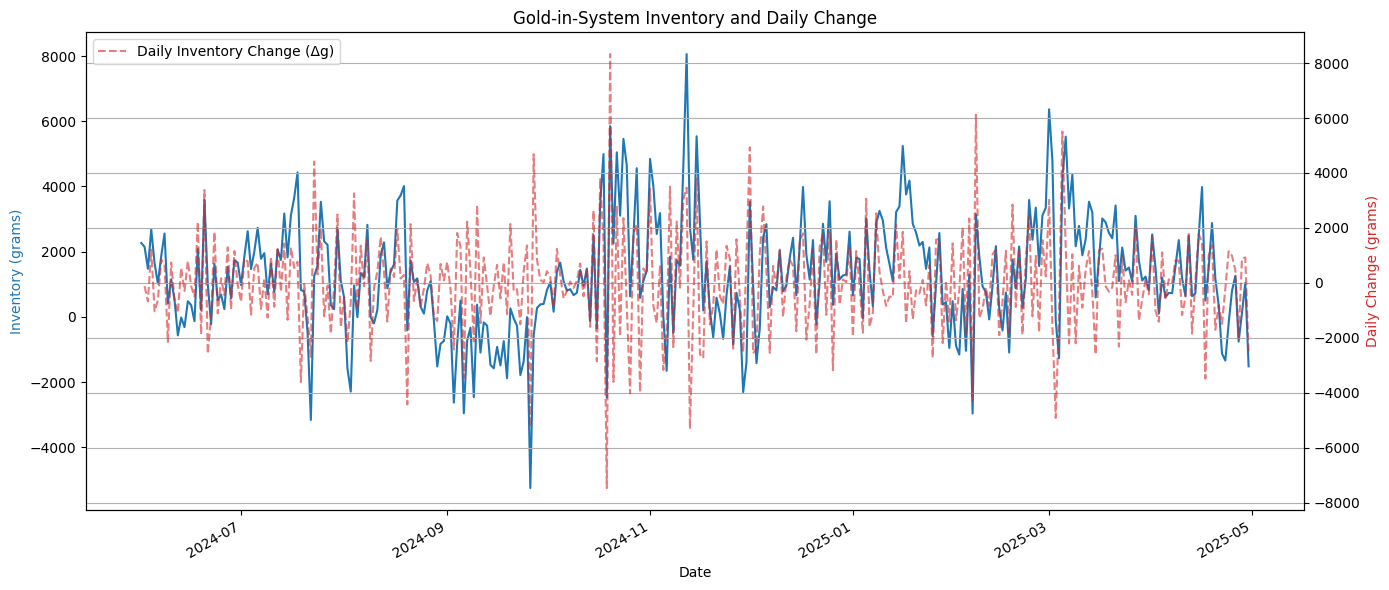

In [5]:
# Compute daily change in inventory (delta)
df['Au_Inventory_Delta'] = df['Au_Inventory_g'].diff()

# Time series setup
df_inventory_plot = df[['Date', 'Au_Inventory_g', 'Au_Inventory_Delta']].copy()
df_inventory_plot['Date'] = pd.to_datetime(df_inventory_plot['Date'], dayfirst=True)
df_inventory_plot.set_index('Date', inplace=True)

# Plot total inventory and change
plt.figure(figsize=(14, 6))
ax1 = df_inventory_plot['Au_Inventory_g'].plot(label='Total Gold-in-System Inventory (g)',
                                               color='tab:blue')
plt.ylabel('Inventory (grams)', color='tab:blue')
plt.title('Gold-in-System Inventory and Daily Change')


# Twin axis for delta
ax2 = ax1.twinx()
df_inventory_plot['Au_Inventory_Delta'].plot(label='Daily Inventory Change (Δg)',
                                             color='tab:red', alpha=0.6, linestyle='--', ax=ax2)
ax2.set_ylabel('Daily Change (grams)', color='tab:red')

plt.grid(True)
plt.tight_layout()
plt.legend(loc='upper left')
plt.show()

#### 🔍 What the plot shows:
* Stable trend over time — no runaway accumulation.
* Confirms the physical system is holding a fairly consistent amount of gold day-to-day.
* Suggests the tank system is in dynamic equilibrium (inflows ≈ outflows).

### ⏳ Carbon Lag Analysis
This plot compares the unaccounted gold when carbon values are shifted by 0, 1, and 2 days:

<Figure size 1200x600 with 0 Axes>

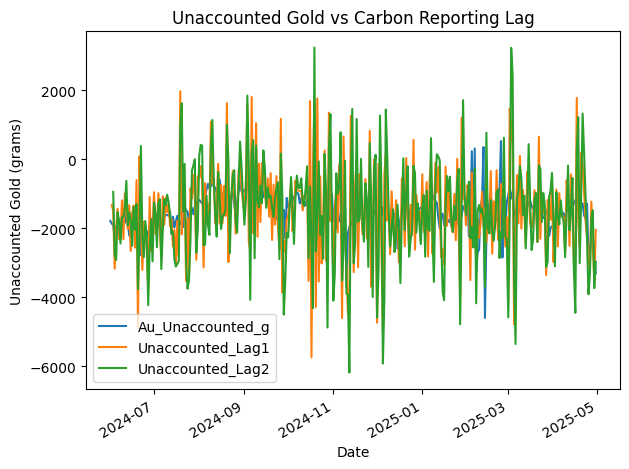

In [6]:
# First, shift carbon reporting by 1 and 2 days to test lag impact
df['Au_on_Carbon_Lag1'] = df['Au_on_Carbon_g'].shift(1)
df['Au_on_Carbon_Lag2'] = df['Au_on_Carbon_g'].shift(2)

# Recompute residuals under each lag assumption
df['Au_Accounted_Lag1'] = (
    df['Au_on_Carbon_Lag1'] +
    df['Total_Au_in_Solution_g'] +
    df['Au_Tailings_g'] +
    df['Undissolved_Au_g']
)

df['Au_Accounted_Lag2'] = (
    df['Au_on_Carbon_Lag2'] +
    df['Total_Au_in_Solution_g'] +
    df['Au_Tailings_g'] +
    df['Undissolved_Au_g']
)

df['Unaccounted_Lag1'] = df['Au_Feed_g'] - df['Au_Accounted_Lag1']
df['Unaccounted_Lag2'] = df['Au_Feed_g'] - df['Au_Accounted_Lag2']

# Time series plot of unaccounted gold with different lag assumptions
df_lag_plot = df[['Date', 'Au_Unaccounted_g', 'Unaccounted_Lag1', 'Unaccounted_Lag2']].copy()
df_lag_plot['Date'] = pd.to_datetime(df_lag_plot['Date'], dayfirst=True)
df_lag_plot.set_index('Date', inplace=True)

plt.figure(figsize=(12, 6))
df_lag_plot.plot()
plt.title('Unaccounted Gold vs Carbon Reporting Lag')
plt.ylabel('Unaccounted Gold (grams)')
plt.grid(False)
plt.tight_layout()
plt.show()


| Line                  | Interpretation                                                                  |
| --------------------- | ------------------------------------------------------------------------------- |
| **Original (no lag)** | Large negative values (carbon appears overstated today)                         |
| **Lag 1 day**         | Discrepancy is reduced — meaning yesterday’s carbon better matches today’s feed |
| **Lag 2 days**        | Discrepancy improves further, but may begin to understate carbon                |

#### **Conclusion**
A 1- to 2-day reporting lag in Gold in Carbon significantly improves reconciliation. This supports the idea that:
* Carbon assays reflect previous gold adsorption, not current-day feed.
* Your recovery model should use lagged carbon values to avoid mismatches.

#### 🧠 Interpretation:
Current accounting **correctly includes** gold held within the CIL circuit (solution + undissolved + tailings). This inventory is not growing uncontrollably, meaning:
* Any residual gap between feed vs recovery is **not due to untracked gold building up in the plant**.
* The issue likely lies in **measurement alignment, recovery % validity**, or **overestimation of recovered gold** (e.g. carbon assay errors or stockpile rounding).

### 📊 Gold-in-System Breakdown
This stacked area chart shows the composition of gold that is not yet recovered:

<Figure size 1400x600 with 0 Axes>

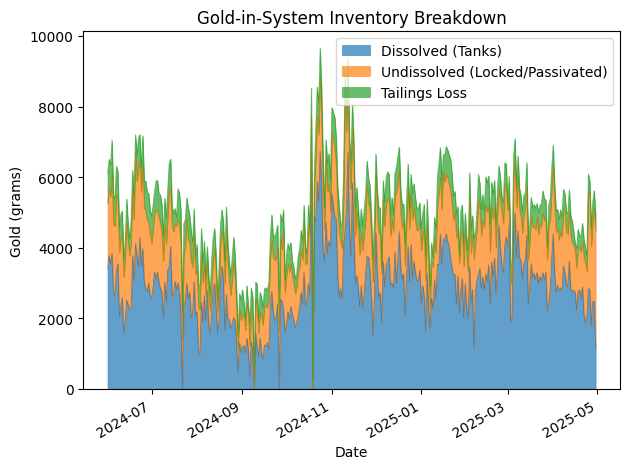

In [7]:
# Prepare time series breakdown of gold-in-system components
df_components = df[['Date',
                    'Total_Au_in_Solution_g',
                    'Undissolved_Au_g',
                    'Au_Tailings_g']].copy()

df_components['Date'] = pd.to_datetime(df_components['Date'], dayfirst=True)
df_components.set_index('Date', inplace=True)

# Rename for clarity
df_components = df_components.rename(columns={
    'Total_Au_in_Solution_g': 'Dissolved (Tanks)',
    'Undissolved_Au_g': 'Undissolved (Locked/Passivated)',
    'Au_Tailings_g': 'Tailings Loss'
})

# Stacked area plot of system inventory components
plt.figure(figsize=(14, 6))
df_components.plot.area(stacked=True, alpha=0.7, linewidth=0.5)
plt.title('Gold-in-System Inventory Breakdown')
plt.ylabel('Gold (grams)')
plt.xlabel('Date')
plt.grid(False)
plt.tight_layout()
plt.show()

#### 🔍 What the plot shows:
* 🟦 Dissolved (Tanks) is the largest contributor
* 🟨 Undissolved (Locked/Passivated) is moderate
* 🟥 Tailings Loss is the smallest

#### 🧠 Interpretation:
* This is valid if Total_Au_in_Solution_g includes all tanks and not just the final CIL.
* It suggests a large gold-in-solution pool, which is plausible for a circuit with:
    - High residence time
    - Poor carbon activity or distribution
    - Limited strip activity or carbon movement

## Build Models
### **1. Recovery Kinetic Model (Mechanistic)**
The core kinetic model is usually based on the de Andrade Lima & Hodouin (2005) framework:

$$𝑅 = 1 − exp⁡[−𝑘_{eff} ⋅ 𝑡] with 𝑘_{eff} = 𝑘_0 ⋅ CN^𝑚 ⋅ DO^𝑛 ⋅ f_{liberation}$$
​
Where:

$𝑅$: recovery (%)
$𝑡$: residence time
$𝑘_{eff}$: effective rate constant
$CN,DO$: cyanide & oxygen concentrations (ppm)
$𝑚,𝑛$: kinetic exponents (fit to data)
$f_{liberation}$: empirical liberation function (e.g. based on particle size and ore mineralogy)

Required inputs:
* Residence time (Residence_Time)
* CN and DO (CN_Concentration_PL_01, Dissolved_Oxygen_PL_01)
* Particle size proxy (Particle_Size or Grade_x_Fines)

### **2. CN Consumption + Loss Model**
Cyanide usage is typically split into:

| Component            | Description                                                                                       |
| -------------------- | ------------------------------------------------------------------------------------------------- |
| **Reagent demand**   | Based on gold and base metal content (e.g. $\text{kg CN/t} = f(\text{Au}, \text{Cu}, \text{Fe})$) |
| **Free cyanide**     | Controlled via setpoints and decays over time                                                     |
| **Loss to tailings** | Based on tail solution concentration × throughput                                                 |
| **Decomposition**    | Reacts with O₂, sulphides, oxidants (thermal or pH-driven)                                        |

We will simulate:
$$CN Loss (kg) = CN in Tailings + CN Decomposition + Other Losses$$

And estimate true plant consumption via:
$$CN Consumed = CN Added − CN Recycled − CN Remaining in Tailings$$

We have:
* Daily_Nacn_Consumption_Kgt
* CN_Tailings_Concentration
* Throughput and Solids_Fraction (to estimate losses)

### **3. Hybrid Model (Fit to Site Data)**
Once you've implemented both models:
* Forward simulation: you input process parameters and simulate expected recovery and CN usage.
* Inverse fitting: use site data to fit:
    - Kinetic exponents $𝑚,𝑛$
    - Liberation function coefficients
    - CN loss constants (baseline loss, decomposition rate, etc.)

In [8]:
# Filter new_period dataset to exclude rows from 1 May 2025 onwards
cutoff_date = pd.Timestamp("2025-05-01")
train_df = df_jan[df_jan["Date"] < cutoff_date].copy()
# train_df = df.copy()
test_df = df_jun[df_jun["Date"] >= cutoff_date].copy()

# Confirm the new filtered date range
train_start = train_df["Date"].min()
train_end = train_df["Date"].max()
latest_start = test_df["Date"].min()
latest_end = test_df["Date"].max()

(train_start, train_end, latest_start, latest_end)

(Timestamp('2025-01-01 00:00:00'),
 Timestamp('2025-04-30 00:00:00'),
 Timestamp('2025-05-01 00:00:00'),
 Timestamp('2025-06-24 00:00:00'))

In [9]:
# Define kinetic model
def gold_recovery_kinetic(cn_ppm, do_ppm, t_hours, particle_size_um,
                          k_base=0.01, cn_exponent=2.0, do_exponent=2.0,
                          liberation_factor=1.0, size_effect_exp=0.0):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_effect_exp
    k_eff = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

# Define features for residual learning
residual_features = [
    "Grade_x_Fines",
    "Particle_Size",
    "Dissolved_Oxygen_PL_01",
    "CN_Concentration_PL_01",
    "Carbon_Concentration_Profile_Gl_Cil_Tank_01",
    "Residence_Time"
]

# Drop NA rows and compute kinetic recovery
train_df = train_df.dropna(subset=residual_features + ["Au_Recovery_pct"])
train_df['Kinetic_Au_Recovery_pct'] = gold_recovery_kinetic(
    train_df['CN_Concentration_PL_01'],
    train_df['Dissolved_Oxygen_PL_01'],
    train_df['Residence_Time'],
    train_df['Particle_Size']
) * 100

train_df['Recovery_Residual'] = train_df['Au_Recovery_pct'] - train_df['Kinetic_Au_Recovery_pct']

# Train residual model
X_train = train_df[residual_features]
y_train = train_df['Recovery_Residual']
xgb_resid_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1, random_state=42)
xgb_resid_model.fit(X_train, y_train)

# Prepare test set
test_df = test_df.dropna(subset=residual_features + ["Au_Recovery_pct"])
test_df['Kinetic_Au_Recovery_pct'] = gold_recovery_kinetic(
    test_df['CN_Concentration_PL_01'],
    test_df['Dissolved_Oxygen_PL_01'],
    test_df['Residence_Time'],
    test_df['Particle_Size']
) * 100

test_df['Recovery_Residual_Pred'] = xgb_resid_model.predict(test_df[residual_features])
test_df['Hybrid_Au_Recovery'] = test_df['Kinetic_Au_Recovery_pct'] + test_df['Recovery_Residual_Pred']

# Evaluate
mae = mean_absolute_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Au_Recovery"])
r2 = r2_score(test_df["Au_Recovery_pct"], test_df["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Au_Recovery"]))

# Display results
print(f"MAE: {mae:.2f} %")
print(f"R^2: {r2:.3f}")
print(f"RMSE: {rmse:.2f} %")

MAE: 1.12 %
R^2: 0.376
RMSE: 1.45 %


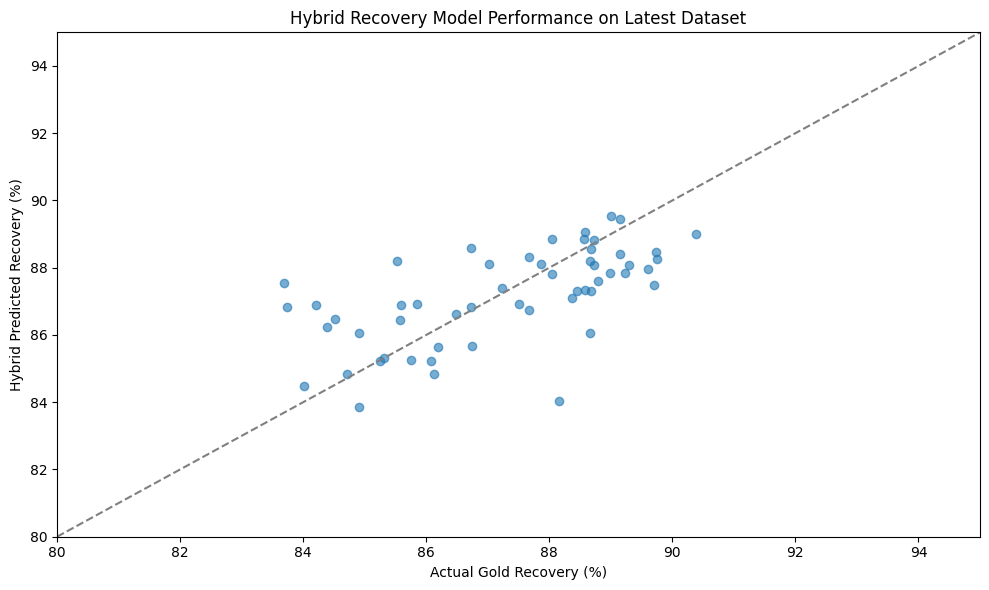

MAE: 1.12 %
R^2: 0.376
RMSE: 1.45 %


In [10]:
# Define kinetic model function
def gold_recovery_kinetic(cn_ppm, do_ppm, t_hours, particle_size_um,
                          k_base=0.01, cn_exponent=2.0, do_exponent=2.0,
                          liberation_factor=1.0, size_effect_exp=0.0):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_effect_exp
    k_eff = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

# Residual model features
residual_features = [
    "Grade_x_Fines",
    "Particle_Size",
    "Dissolved_Oxygen_PL_01",
    "CN_Concentration_PL_01",
    "Carbon_Concentration_Profile_Gl_Cil_Tank_01",
    "Residence_Time"
]

# Prepare training data
train_df = train_df.dropna(subset=residual_features + ["Au_Recovery_pct"]).copy()
train_df['Kinetic_Au_Recovery_pct'] = gold_recovery_kinetic(
    train_df['CN_Concentration_PL_01'],
    train_df['Dissolved_Oxygen_PL_01'],
    train_df['Residence_Time'],
    train_df['Particle_Size']
) * 100
train_df['Recovery_Residual'] = train_df['Au_Recovery_pct'] - train_df['Kinetic_Au_Recovery_pct']

# Train residual model
X_train = train_df[residual_features]
y_train = train_df['Recovery_Residual']
xgb_model = XGBRegressor(n_estimators=100, max_depth=4, learning_rate=0.1)
xgb_model.fit(X_train, y_train)

# Prepare test data
test_df = test_df.dropna(subset=residual_features + ["Au_Recovery_pct"]).copy()
test_df['Kinetic_Au_Recovery_pct'] = gold_recovery_kinetic(
    test_df['CN_Concentration_PL_01'],
    test_df['Dissolved_Oxygen_PL_01'],
    test_df['Residence_Time'],
    test_df['Particle_Size']
) * 100
test_df['Recovery_Residual_Pred'] = xgb_model.predict(test_df[residual_features])
test_df['Hybrid_Au_Recovery'] = test_df['Kinetic_Au_Recovery_pct'] + test_df['Recovery_Residual_Pred']

# Evaluate performance
mae = mean_absolute_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Au_Recovery"])
r2 = r2_score(test_df["Au_Recovery_pct"], test_df["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(test_df["Au_Recovery_pct"], test_df["Hybrid_Au_Recovery"]))

# Plotting
plt.figure(figsize=(10, 6))
plt.scatter(test_df["Au_Recovery_pct"], test_df["Hybrid_Au_Recovery"], alpha=0.6)
plt.plot([0, 100], [0, 100], linestyle='--', color='grey')
plt.xlabel("Actual Gold Recovery (%)")
plt.ylabel("Hybrid Predicted Recovery (%)")
plt.title("Hybrid Recovery Model Performance on Latest Dataset")
plt.grid(False)
plt.ylim(80, 95)
plt.xlim(80, 95)
plt.tight_layout()
plt.show()

# Display results
print(f"MAE: {mae:.2f} %")
print(f"R^2: {r2:.3f}")
print(f"RMSE: {rmse:.2f} %")


In [11]:
df_train = df_jan[df_jan["Date"] < cutoff_date].copy()
df_test = df_jun[df_jun["Date"] >= cutoff_date].copy()

In [12]:
# --- Step 1: Define kinetic model ---
def gold_recovery_kinetic(cn_ppm, do_ppm, t_hours, particle_size_um,
                          k_base=0.01, cn_exponent=2.0, do_exponent=2.0,
                          liberation_factor=1.0, size_effect_exp=0.0):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_effect_exp
    k_eff = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

# --- Step 2: Define input features ---
residual_features = [
    "Grade_x_Fines",
    "Particle_Size",
    "Dissolved_Oxygen_PL_01",
    "CN_Concentration_PL_01",
    "Carbon_Concentration_Profile_Gl_Cil_Tank_01",
    "Residence_Time"
]

# --- Step 3: Prepare training data ---
df_train_clean = df_train.dropna(subset=residual_features + ["Au_Recovery_pct", "Residence_Time"]).copy()

# --- Step 4: Apply kinetic model to training data ---
df_train_clean['Kinetic_Au_Recovery_pct'] = gold_recovery_kinetic(
    df_train_clean['CN_Concentration_PL_01'],
    df_train_clean['Dissolved_Oxygen_PL_01'],
    df_train_clean['Residence_Time'],
    df_train_clean['Particle_Size']
) * 100

# --- Step 5: Calculate residuals ---
df_train_clean['Recovery_Residual'] = df_train_clean['Au_Recovery_pct'] - df_train_clean['Kinetic_Au_Recovery_pct']

# --- Step 6: Fit XGBoost model to residuals ---
X_train = df_train_clean[residual_features]
y_train = df_train_clean['Recovery_Residual']

xgb_resid_model = XGBRegressor(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42
)
xgb_resid_model.fit(X_train, y_train)


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=4, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=None,
             num_parallel_tree=None, random_state=42, ...)

🔍 Hybrid Model Performance on Test Dataset:
R² Score:             0.3759
Mean Absolute Error:  1.12 %
Root Mean Squared Error: 1.45 %


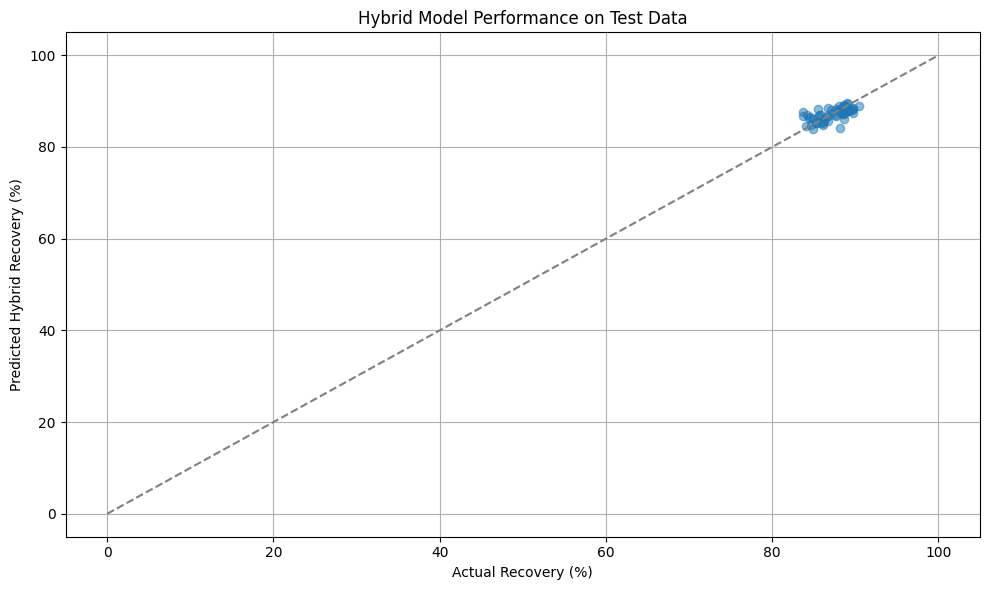

In [13]:
# --- Step 1: Drop rows with missing inputs ---
df_test_clean = df_test.dropna(subset=residual_features + ["Au_Recovery_pct", "Residence_Time"]).copy()

# --- Step 2: Apply kinetic model to test set ---
df_test_clean["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test_clean["CN_Concentration_PL_01"],
    df_test_clean["Dissolved_Oxygen_PL_01"],
    df_test_clean["Residence_Time"],
    df_test_clean["Particle_Size"]
) * 100

# --- Step 3: Predict residuals using trained XGB model ---
df_test_clean["Recovery_Residual_Pred"] = xgb_resid_model.predict(df_test_clean[residual_features])

# --- Step 4: Combine kinetic + residuals for hybrid recovery ---
df_test_clean["Hybrid_Au_Recovery"] = df_test_clean["Kinetic_Au_Recovery_pct"] + df_test_clean["Recovery_Residual_Pred"]

# --- Step 5: Clamp to [0, 100] % ---
df_test_clean["Hybrid_Au_Recovery"] = df_test_clean["Hybrid_Au_Recovery"].clip(lower=0, upper=100)

# --- Step 6: Evaluate metrics ---
mae = mean_absolute_error(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"])
r2 = r2_score(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"]))

# --- Step 7: Display results ---
print("🔍 Hybrid Model Performance on Test Dataset:")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")

# --- Step 8: Plot Actual vs Predicted Recovery ---
plt.figure(figsize=(10, 6))
plt.scatter(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"], alpha=0.5)
plt.plot([0, 100], [0, 100], linestyle="--", color="grey")
plt.xlabel("Actual Recovery (%)")
plt.ylabel("Predicted Hybrid Recovery (%)")
plt.title("Hybrid Model Performance on Test Data")
plt.grid(True)
plt.tight_layout()
plt.show()


In [14]:
# --- Step 1: Recompute kinetic baseline on training set ---
df_train["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_train["CN_Concentration_PL_01"],
    df_train["Dissolved_Oxygen_PL_01"],
    df_train["Residence_Time"],
    df_train["Particle_Size"]
) * 100

# --- Step 2: Recompute residuals (actual - kinetic) ---
df_train["Recovery_Residual"] = df_train["Au_Recovery_pct"] - df_train["Kinetic_Au_Recovery_pct"]

# --- Step 3: Drop any missing rows for clean training ---
df_train_clean = df_train.dropna(subset=residual_features + ["Recovery_Residual"])

# --- Step 4: Refit XGB residual model with more capacity ---
xgb_resid_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_resid_model.fit(df_train_clean[residual_features], df_train_clean["Recovery_Residual"])

# --- Step 5: Print feature importances ---
importances = xgb_resid_model.feature_importances_
for name, score in zip(residual_features, importances):
    print(f"{name:40s} {score:.4f}")


Grade_x_Fines                            0.2714
Particle_Size                            0.0593
Dissolved_Oxygen_PL_01                   0.4527
CN_Concentration_PL_01                   0.1061
Carbon_Concentration_Profile_Gl_Cil_Tank_01 0.0539
Residence_Time                           0.0566


In [15]:
# --- Step 1: Extend training set with engineered features ---
df_train_ext = df_train_clean.copy()

# Interaction and nonlinear terms
df_train_ext["CNxDO"] = df_train_ext["CN_Concentration_PL_01"] * df_train_ext["Dissolved_Oxygen_PL_01"]
df_train_ext["Grade_x_Fines_Sqrt"] = np.sqrt(df_train_ext["Grade_x_Fines"])
df_train_ext["Log_DO"] = np.log1p(df_train_ext["Dissolved_Oxygen_PL_01"])
df_train_ext["CN2"] = df_train_ext["CN_Concentration_PL_01"] ** 2
df_train_ext["Grade_x_Fines_x_Residence_Time"] = df_train_ext["Grade_x_Fines"] * df_train_ext["Residence_Time"]

# New feature list
residual_features_ext = residual_features + [
    "CNxDO",
    "Grade_x_Fines_Sqrt",
    "Log_DO",
    "CN2",
    "Grade_x_Fines_x_Residence_Time"
]

# --- Step 2: Refit XGBoost model on extended features ---
xgb_resid_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_resid_model.fit(df_train_ext[residual_features_ext], df_train_ext["Recovery_Residual"])

# --- Step 3: Feature importances ---
importances = xgb_resid_model.feature_importances_
for name, score in zip(residual_features_ext, importances):
    print(f"{name:45s} {score:.4f}")


Grade_x_Fines                                 0.0608
Particle_Size                                 0.0217
Dissolved_Oxygen_PL_01                        0.2509
CN_Concentration_PL_01                        0.0260
Carbon_Concentration_Profile_Gl_Cil_Tank_01   0.0208
Residence_Time                                0.0155
CNxDO                                         0.0364
Grade_x_Fines_Sqrt                            0.0923
Log_DO                                        0.3886
CN2                                           0.0136
Grade_x_Fines_x_Residence_Time                0.0735


In [16]:
# --- Step 1: Apply the same feature engineering to the test set ---
df_test_ext = df_test_clean.copy()

df_test_ext["CNxDO"] = df_test_ext["CN_Concentration_PL_01"] * df_test_ext["Dissolved_Oxygen_PL_01"]
df_test_ext["Grade_x_Fines_Sqrt"] = np.sqrt(df_test_ext["Grade_x_Fines"])
df_test_ext["Log_DO"] = np.log1p(df_test_ext["Dissolved_Oxygen_PL_01"])
df_test_ext["CN2"] = df_test_ext["CN_Concentration_PL_01"] ** 2
df_test_ext["Grade_x_Fines_x_Residence_Time"] = df_test_ext["Grade_x_Fines"] * df_test_ext["Residence_Time"]

# --- Step 2: Recompute kinetic recovery ---
df_test_ext["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test_ext["CN_Concentration_PL_01"],
    df_test_ext["Dissolved_Oxygen_PL_01"],
    df_test_ext["Residence_Time"],
    df_test_ext["Particle_Size"]
) * 100

# --- Step 3: Predict residuals and combine ---
df_test_ext["Recovery_Residual_Pred"] = xgb_resid_model.predict(df_test_ext[residual_features_ext])
df_test_ext["Hybrid_Au_Recovery"] = df_test_ext["Kinetic_Au_Recovery_pct"] + df_test_ext["Recovery_Residual_Pred"]

# --- Step 4: Evaluation ---
df_eval_ext = df_test_ext.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"]).copy()

mae = mean_absolute_error(df_eval_ext["Au_Recovery_pct"], df_eval_ext["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval_ext["Au_Recovery_pct"], df_eval_ext["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval_ext["Au_Recovery_pct"], df_eval_ext["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance on Extended Test Set:")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance on Extended Test Set:
R² Score:             0.4127
Mean Absolute Error:  1.11 %
Root Mean Squared Error: 1.40 %


In [17]:
# --- Step 1: Redefine model with tuned hyperparameters ---
xgb_resid_model = XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=0.2,
    min_child_weight=3,
    random_state=42
)

# --- Step 2: Retrain on extended feature set ---
X_resid_ext = df_train_ext[residual_features_ext]
y_resid = df_train_ext["Recovery_Residual"]

xgb_resid_model.fit(X_resid_ext, y_resid)

# --- Step 3: Predict residuals and combine ---
df_test_ext["Recovery_Residual_Pred"] = xgb_resid_model.predict(df_test_ext[residual_features_ext])
df_test_ext["Hybrid_Au_Recovery"] = df_test_ext["Kinetic_Au_Recovery_pct"] + df_test_ext["Recovery_Residual_Pred"]

# --- Step 4: Evaluation ---
df_eval_ext = df_test_ext.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"]).copy()

mae = mean_absolute_error(df_eval_ext["Au_Recovery_pct"], df_eval_ext["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval_ext["Au_Recovery_pct"], df_eval_ext["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval_ext["Au_Recovery_pct"], df_eval_ext["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance on Extended Test Set:")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")


🔍 Hybrid Model Performance on Extended Test Set:
R² Score:             0.4122
Mean Absolute Error:  1.08 %
Root Mean Squared Error: 1.40 %


In [18]:
# --- Step 1: Train a Random Forest on residuals ---
rf_resid_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

rf_resid_model.fit(X_resid_ext, y_resid)

# --- Step 2: Predict residuals using Random Forest ---
df_test_ext["Recovery_Residual_Pred"] = rf_resid_model.predict(df_test_ext[residual_features_ext])

# --- Step 3: Compute hybrid recovery ---
df_test_ext["Hybrid_Au_Recovery"] = df_test_ext["Kinetic_Au_Recovery_pct"] + df_test_ext["Recovery_Residual_Pred"]

# --- Step 4: Evaluate performance ---
df_eval_rf = df_test_ext.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval_rf["Au_Recovery_pct"], df_eval_rf["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval_rf["Au_Recovery_pct"], df_eval_rf["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval_rf["Au_Recovery_pct"], df_eval_rf["Hybrid_Au_Recovery"]))

print("🔍 Hybrid Model Performance (Kinetic + Random Forest Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")


🔍 Hybrid Model Performance (Kinetic + Random Forest Residual Correction):
R² Score:             0.3841
Mean Absolute Error:  1.05 %
Root Mean Squared Error: 1.44 %


In [19]:
# --- Base learners: XGBoost and Linear Model ---
base_learners = [
    ('xgb', XGBRegressor(n_estimators=300, max_depth=5, learning_rate=0.1, random_state=42)),
    ('ridge', Ridge(alpha=1.0))
]

# --- Stacking model ---
stacked_model = StackingRegressor(
    estimators=base_learners,
    final_estimator=Ridge(alpha=0.5),
    n_jobs=-1
)

# --- Fit to residuals ---
stacked_model.fit(X_resid_ext, y_resid)

# Predict residuals
df_test_ext["Recovery_Residual_Pred"] = stacked_model.predict(df_test_ext[residual_features_ext])

# Compute hybrid recovery
df_test_ext["Hybrid_Au_Recovery"] = df_test_ext["Kinetic_Au_Recovery_pct"] + df_test_ext["Recovery_Residual_Pred"]

# Evaluate
df_eval_stack = df_test_ext.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval_stack["Au_Recovery_pct"], df_eval_stack["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval_stack["Au_Recovery_pct"], df_eval_stack["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval_stack["Au_Recovery_pct"], df_eval_stack["Hybrid_Au_Recovery"]))

print("🔍 Hybrid Model Performance (Kinetic + Stacked Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")


🔍 Hybrid Model Performance (Kinetic + Stacked Residual Correction):
R² Score:             0.1067
Mean Absolute Error:  1.43 %
Root Mean Squared Error: 1.73 %


In [20]:
# Extended residual features
residual_features_ext = [
    "Grade_x_Fines",
    "Particle_Size",
    "Dissolved_Oxygen_PL_01",
    "CN_Concentration_PL_01",
    "Carbon_Concentration_Profile_Gl_Cil_Tank_01",
    "Residence_Time",
    "CNxDO",
    "Grade_x_Fines_Sqrt",
    "Log_DO",
    "CN2",
    "Grade_x_Fines_x_Residence_Time"
]

# Add engineered features to both datasets
for df_ in [df_train, df_test]:
    df_["CNxDO"] = df_["CN_Concentration_PL_01"] * df_["Dissolved_Oxygen_PL_01"]
    df_["Grade_x_Fines_Sqrt"] = np.sqrt(df_["Grade_x_Fines"])
    df_["Log_DO"] = np.log1p(df_["Dissolved_Oxygen_PL_01"])
    df_["CN2"] = df_["CN_Concentration_PL_01"] ** 2
    df_["Grade_x_Fines_x_Residence_Time"] = df_["Grade_x_Fines"] * df_["Residence_Time"]


# Select fields for clustering
cluster_fields = ["CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01"]
X_cluster = df_train[cluster_fields].dropna()

# Fit KMeans
kmeans = KMeans(n_clusters=2, random_state=42)
df_train["CN_Regime"] = kmeans.fit_predict(df_train[cluster_fields])

# Assign regimes to test set
df_test["CN_Regime"] = kmeans.predict(df_test[cluster_fields])

models_by_regime = {}
for regime in sorted(df_train["CN_Regime"].unique()):
    # Filter for regime
    df_regime = df_train[df_train["CN_Regime"] == regime].dropna(subset=residual_features_ext + ["Recovery_Residual"])
    
    # Train XGB
    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
    model.fit(df_regime[residual_features_ext], df_regime["Recovery_Residual"])
    
    models_by_regime[regime] = model

# Apply hybrid model using regime-specific residual models
preds = []
for i, row in df_test.iterrows():
    regime = row["CN_Regime"]
    model = models_by_regime.get(regime)
    if model:
        input_features = row[residual_features_ext].values.reshape(1, -1)
        pred = model.predict(input_features)[0]
    else:
        pred = 0  # fallback
    preds.append(pred)

# Define the kinetic model if not already defined
def gold_recovery_kinetic(cn_ppm, do_ppm, t_hours, particle_size_um,
                          k_base=0.01, cn_exponent=2.0, do_exponent=2.0,
                          liberation_factor=1.0, size_effect_exp=0.0):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_effect_exp
    k_eff = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

# Calculate kinetic recovery on test set
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100



# Compute hybrid recovery
df_test["Recovery_Residual_Pred"] = preds
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# Evaluate
df_eval_kmeans = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval_kmeans["Au_Recovery_pct"], df_eval_kmeans["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval_kmeans["Au_Recovery_pct"], df_eval_kmeans["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval_kmeans["Au_Recovery_pct"], df_eval_kmeans["Hybrid_Au_Recovery"]))

print("🔍 Hybrid Model Performance (Per-Regime XGBoost Residuals):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")


🔍 Hybrid Model Performance (Per-Regime XGBoost Residuals):
R² Score:             0.2469
Mean Absolute Error:  1.23 %
Root Mean Squared Error: 1.59 %


In [21]:
# Define grade bins (adjust if needed)
df_train["Grade_Bin"] = pd.qcut(df_train["Grade_x_Fines"], q=4, labels=False, duplicates="drop")
df_test["Grade_Bin"] = pd.cut(df_test["Grade_x_Fines"], bins=np.quantile(df_train["Grade_x_Fines"], [0, 0.25, 0.5, 0.75, 1]), labels=False, include_lowest=True)

# Recalculate kinetic recovery on both sets (if not already present)
df_train["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_train["CN_Concentration_PL_01"],
    df_train["Dissolved_Oxygen_PL_01"],
    df_train["Residence_Time"],
    df_train["Particle_Size"]
) * 100

df_train["Recovery_Residual"] = df_train["Au_Recovery_pct"] - df_train["Kinetic_Au_Recovery_pct"]

# Train a separate model for each grade bin
models_by_bin = {}
for bin_id in sorted(df_train["Grade_Bin"].dropna().unique()):
    df_bin = df_train[df_train["Grade_Bin"] == bin_id].dropna(subset=residual_features_ext + ["Recovery_Residual"])
    model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
    model.fit(df_bin[residual_features_ext], df_bin["Recovery_Residual"])
    models_by_bin[bin_id] = model

# Apply to test set
preds = []
for _, row in df_test.iterrows():
    bin_id = row["Grade_Bin"]
    if pd.isna(bin_id) or bin_id not in models_by_bin:
        preds.append(np.nan)
    else:
        features = row[residual_features_ext].values.reshape(1, -1)
        pred = models_by_bin[bin_id].predict(features)[0]
        preds.append(pred)

df_test["Recovery_Residual_Pred"] = preds

# Compute hybrid model
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# Evaluate
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (Per-GradeBin Residuals):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (Per-GradeBin Residuals):
R² Score:             -0.0899
Mean Absolute Error:  1.58 %
Root Mean Squared Error: 1.91 %


In [22]:
# Fit Kinetic model on train set if not already done
df_train["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_train["CN_Concentration_PL_01"],
    df_train["Dissolved_Oxygen_PL_01"],
    df_train["Residence_Time"],
    df_train["Particle_Size"]
) * 100

# Residual target
df_train["Recovery_Residual"] = df_train["Au_Recovery_pct"] - df_train["Kinetic_Au_Recovery_pct"]

# Train KNN regressor on residuals
knn_resid_model = KNeighborsRegressor(n_neighbors=15, weights='distance')
knn_resid_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# Predict residuals on test set
df_test["Recovery_Residual_Pred"] = knn_resid_model.predict(df_test[residual_features_ext])

# Recompute kinetic model on test set
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# Final hybrid model
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# Evaluation
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (KNN Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (KNN Residual Correction):
R² Score:             -0.4884
Mean Absolute Error:  1.77 %
Root Mean Squared Error: 2.23 %


In [23]:
# --- Preprocessing: Scale features ---
scaler = StandardScaler()
X_resid_train_scaled = scaler.fit_transform(df_train[residual_features_ext])
X_resid_test_scaled = scaler.transform(df_test[residual_features_ext])

# --- Target: Residuals from kinetic model ---
df_train["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_train["CN_Concentration_PL_01"],
    df_train["Dissolved_Oxygen_PL_01"],
    df_train["Residence_Time"],
    df_train["Particle_Size"]
) * 100
df_train["Recovery_Residual"] = df_train["Au_Recovery_pct"] - df_train["Kinetic_Au_Recovery_pct"]

# --- Fit Gaussian Process Regressor ---
kernel = C(1.0) * RBF(length_scale=1.0)
gpr_model = GaussianProcessRegressor(kernel=kernel, alpha=0.1, normalize_y=True)
gpr_model.fit(X_resid_train_scaled, df_train["Recovery_Residual"])

# --- Predict residuals on test set ---
df_test["Recovery_Residual_Pred"] = gpr_model.predict(X_resid_test_scaled)

# --- Kinetic recovery on test set ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Hybrid recovery ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (Gaussian Process Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (Gaussian Process Residual Correction):
R² Score:             0.1170
Mean Absolute Error:  1.32 %
Root Mean Squared Error: 1.72 %


In [24]:
# --- Scale residual input features ---
scaler_loess = StandardScaler()
X_train_scaled = scaler_loess.fit_transform(df_train[residual_features_ext])
X_test_scaled = scaler_loess.transform(df_test[residual_features_ext])

# --- Kinetic model + residuals ---
df_train["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_train["CN_Concentration_PL_01"],
    df_train["Dissolved_Oxygen_PL_01"],
    df_train["Residence_Time"],
    df_train["Particle_Size"]
) * 100
df_train["Recovery_Residual"] = df_train["Au_Recovery_pct"] - df_train["Kinetic_Au_Recovery_pct"]

# --- LOESS-like KNN model with distance weights ---
loess_model = KNeighborsRegressor(n_neighbors=25, weights="distance", metric="euclidean")
loess_model.fit(X_train_scaled, df_train["Recovery_Residual"])

# --- Predict residuals on test set ---
df_test["Recovery_Residual_Pred"] = loess_model.predict(X_test_scaled)

# --- Recalculate kinetic recovery for test set ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Hybrid prediction ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (LOESS-style Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (LOESS-style Residual Correction):
R² Score:             0.0062
Mean Absolute Error:  1.51 %
Root Mean Squared Error: 1.83 %


In [25]:
# --- Train LightGBM on residuals ---
X_train_lgb = df_train[residual_features_ext].copy()
y_train_lgb = df_train["Recovery_Residual"].copy()

lgb_train = lgb.Dataset(X_train_lgb, label=y_train_lgb)
lgb_params = {
    "objective": "regression",
    "metric": "rmse",
    "verbosity": -1,
    "boosting_type": "gbdt",
    "learning_rate": 0.05,
    "num_leaves": 31,
    "max_depth": 5,
    "seed": 42
}
lgb_model = lgb.train(params=lgb_params, train_set=lgb_train, num_boost_round=200)

# --- Predict residuals on test set ---
df_test["Recovery_Residual_Pred"] = lgb_model.predict(df_test[residual_features_ext])

# --- Recalculate kinetic recovery ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Hybrid prediction ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (LightGBM Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (LightGBM Residual Correction):
R² Score:             0.5114
Mean Absolute Error:  0.98 %
Root Mean Squared Error: 1.28 %


In [26]:
# --- Train CatBoost on residuals ---
cat_model = CatBoostRegressor(
    iterations=300,
    learning_rate=0.05,
    depth=5,
    verbose=0,
    random_state=42
)

X_train_cat = df_train[residual_features_ext]
y_train_cat = df_train["Recovery_Residual"]
cat_model.fit(X_train_cat, y_train_cat)

# --- Predict residuals on test set ---
df_test["Recovery_Residual_Pred"] = cat_model.predict(df_test[residual_features_ext])

# --- Recalculate kinetic recovery ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Hybrid prediction ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (CatBoost Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (CatBoost Residual Correction):
R² Score:             0.5196
Mean Absolute Error:  0.97 %
Root Mean Squared Error: 1.27 %


In [27]:
# --- ElasticNet Residual Model ---
enet_model = ElasticNetCV(cv=5, l1_ratio=0.5, alphas=np.logspace(-4, 1, 50), random_state=42,
                          max_iter=10000)
X_train_enet = df_train[residual_features_ext]
y_train_enet = df_train["Recovery_Residual"]
enet_model.fit(X_train_enet, y_train_enet)

# --- Predict on test set ---
df_test["Recovery_Residual_Pred"] = enet_model.predict(df_test[residual_features_ext])

# --- Recalculate kinetic baseline ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Combine to hybrid recovery ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate performance ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (ElasticNet Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (ElasticNet Residual Correction):
R² Score:             0.1350
Mean Absolute Error:  1.37 %
Root Mean Squared Error: 1.70 %


In [28]:
# --- CatBoost ---
cat_model = CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)
cat_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# --- LightGBM ---
lgb_model = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
lgb_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# --- ElasticNet ---
enet_model = ElasticNetCV(cv=5, l1_ratio=0.5, alphas=np.logspace(-4, 1, 50), random_state=42,
                          max_iter=10000)
enet_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# --- Predict residuals on test set ---
cat_pred = cat_model.predict(df_test[residual_features_ext])
lgb_pred = lgb_model.predict(df_test[residual_features_ext])
enet_pred = enet_model.predict(df_test[residual_features_ext])

# --- Weighted ensemble ---
df_test["Recovery_Residual_Pred"] = (0.4 * cat_pred + 0.4 * lgb_pred + 0.2 * enet_pred)

# --- Recalculate kinetic baseline ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Hybrid recovery ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (Ensemble of CatBoost + LightGBM + ElasticNet):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (Ensemble of CatBoost + LightGBM + ElasticNet):
R² Score:             0.4814
Mean Absolute Error:  1.04 %
Root Mean Squared Error: 1.32 %


In [29]:
# --- Refit individual models ---
xgb_model = XGBRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
xgb_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

lgb_model = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
lgb_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

enet_model = ElasticNetCV(cv=5, l1_ratio=0.5, alphas=np.logspace(-4, 1, 50), random_state=42,
                          max_iter=10000)
enet_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# --- Predict residuals ---
xgb_pred = xgb_model.predict(df_test[residual_features_ext])
lgb_pred = lgb_model.predict(df_test[residual_features_ext])
enet_pred = enet_model.predict(df_test[residual_features_ext])

# --- Weighted ensemble prediction ---
df_test["Recovery_Residual_Pred"] = (0.4 * xgb_pred + 0.4 * lgb_pred + 0.2 * enet_pred)

# --- Kinetic baseline ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Final hybrid prediction ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (Ensemble of XGBoost + LightGBM + ElasticNet):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (Ensemble of XGBoost + LightGBM + ElasticNet):
R² Score:             0.4883
Mean Absolute Error:  1.06 %
Root Mean Squared Error: 1.31 %


In [30]:
# --- Refit models on training data ---
cat_model = CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)
cat_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

enet_model = ElasticNetCV(cv=5, l1_ratio=0.5, alphas=np.logspace(-4, 1, 50), max_iter=10000,
                          random_state=42)
enet_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# --- Predict residuals ---
cat_pred = cat_model.predict(df_test[residual_features_ext])
enet_pred = enet_model.predict(df_test[residual_features_ext])

# --- Weighted ensemble prediction ---
df_test["Recovery_Residual_Pred"] = (0.7 * cat_pred + 0.3 * enet_pred)

# --- Kinetic baseline ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Final hybrid prediction ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (CatBoost + ElasticNet Ensemble):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (CatBoost + ElasticNet Ensemble):
R² Score:             0.4546
Mean Absolute Error:  1.08 %
Root Mean Squared Error: 1.35 %


In [31]:
# Train the HistGradientBoosting model
hgb_model = HistGradientBoostingRegressor(
    max_iter=300,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)
hgb_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# Predict residuals
df_test["Recovery_Residual_Pred"] = hgb_model.predict(df_test[residual_features_ext])

# Compute hybrid recovery
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# Evaluate
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (HistGradientBoosting Residual Correction):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (HistGradientBoosting Residual Correction):
R² Score:             0.3293
Mean Absolute Error:  1.20 %
Root Mean Squared Error: 1.50 %


In [32]:
# Refit CatBoost model
cat_model = CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)
cat_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# Refit LightGBM model
lgb_model = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
lgb_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# Predict residuals using both models
cat_pred = cat_model.predict(df_test[residual_features_ext])
lgb_pred = lgb_model.predict(df_test[residual_features_ext])

# Weighted ensemble (you can tune the weights later)
df_test["Recovery_Residual_Pred"] = 0.5 * cat_pred + 0.5 * lgb_pred

# Compute kinetic recovery
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# Final hybrid recovery
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# Evaluate
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (CatBoost + LightGBM Ensemble):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (CatBoost + LightGBM Ensemble):
R² Score:             0.4915
Mean Absolute Error:  1.01 %
Root Mean Squared Error: 1.31 %


In [33]:
# Fit CatBoost
cat_model = CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)
cat_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# Fit LightGBM
lgb_model = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
lgb_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# Fit ElasticNetCV (with warnings suppressed)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    enet_model = ElasticNetCV(cv=5, l1_ratio=0.5, alphas=np.logspace(-4, 1, 50), random_state=42, max_iter=10000)
    enet_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# Predict residuals
cat_pred = cat_model.predict(df_test[residual_features_ext])
lgb_pred = lgb_model.predict(df_test[residual_features_ext])
enet_pred = enet_model.predict(df_test[residual_features_ext])

# Weighted ensemble prediction (CatBoost > LightGBM > ElasticNet)
df_test["Recovery_Residual_Pred"] = (
    0.5 * cat_pred +
    0.3 * lgb_pred +
    0.2 * enet_pred
)

# Kinetic baseline
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# Final hybrid prediction
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# Evaluate
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (CatBoost + LightGBM + ElasticNet Ensemble):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (CatBoost + LightGBM + ElasticNet Ensemble):
R² Score:             0.4849
Mean Absolute Error:  1.04 %
Root Mean Squared Error: 1.31 %


In [34]:
# --- Define base regressors ---
base_models = [
    ("cat", CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)),
    ("lgb", LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)),
    ("enet", ElasticNetCV(cv=5, l1_ratio=0.5, alphas=np.logspace(-4, 1, 50), random_state=42,
                          max_iter=10000))
]

# --- Define meta-learner ---
meta_model = ElasticNetCV(cv=5, l1_ratio=0.5, alphas=np.logspace(-4, 1, 50), random_state=42,
                          max_iter=10000)

# --- Build stacking model ---
stack_model = StackingRegressor(
    estimators=base_models,
    final_estimator=meta_model,
    cv=5,
    passthrough=True,
    n_jobs=-1
)

# --- Fit on training data ---
stack_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# --- Predict residuals ---
df_test["Recovery_Residual_Pred"] = stack_model.predict(df_test[residual_features_ext])

# --- Kinetic baseline ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Final hybrid prediction ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (Stacked Regressor):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (Stacked Regressor):
R² Score:             0.1062
Mean Absolute Error:  1.48 %
Root Mean Squared Error: 1.73 %


In [35]:
def predict_hybrid_recovery(df, cat_model, lgbm_model, kinetic_func, feature_cols,
                            cn_col="CN_Concentration_PL_01",
                            do_col="Dissolved_Oxygen_PL_01",
                            rt_col="Residence_Time",
                            size_col="Particle_Size"):
    """
    Predicts hybrid gold recovery using kinetic baseline + CatBoost + LightGBM ensemble.
    
    Parameters:
        df (pd.DataFrame): DataFrame with necessary columns
        cat_model (CatBoostRegressor): Trained CatBoost model
        lgbm_model (LGBMRegressor): Trained LightGBM model
        kinetic_func (function): Function to calculate kinetic recovery
        feature_cols (list): Columns used in residual prediction
        cn_col, do_col, rt_col, size_col (str): Column names for kinetic inputs
    
    Returns:
        pd.DataFrame: Original df + predicted columns
    """

    df = df.copy()

    # --- Kinetic baseline ---
    df["Kinetic_Au_Recovery_pct"] = kinetic_func(
        df[cn_col],
        df[do_col],
        df[rt_col],
        df[size_col]
    ) * 100

    # --- Residual correction ensemble ---
    df["Recovery_Residual_Pred"] = 0.5 * cat_model.predict(df[feature_cols]) + \
                                   0.5 * lgbm_model.predict(df[feature_cols])

    # --- Final hybrid prediction ---
    df["Hybrid_Au_Recovery"] = df["Kinetic_Au_Recovery_pct"] + df["Recovery_Residual_Pred"]

    return df


In [36]:
# Create example structure for implementation
# This cell will provide:
# - 1. Date filter logic (Jun-Dec 2024 inclusion)
# - 2. Unstable period flagging
# - 3. Downweighting logic (optional)
# - Plus confirmation of kinetic vs ML logic being used

# Sample data structure setup
date_range = pd.date_range(start="2024-06-01", end="2025-05-31", freq="D")
df_sample = pd.DataFrame({
    "Date": date_range,
    "CN_Concentration_PL_01": 500 + (50 * (pd.Series(range(len(date_range))) % 12)),
    "Dissolved_Oxygen_PL_01": 5.0,
    "Residence_Time": 24.0,
    "Particle_Size": 75.0,
    "Au_Recovery_pct": 90.0
})
df_sample["Date"] = pd.to_datetime(df_sample["Date"])

# Apply 1. Filter to include all dates
df_all = df.copy()

# Apply 2. Add a flag for known "unstable" CN period (Jun-Dec 2024)
df_all["CN_Supply_Unstable"] = df_all["Date"].between("2024-06-01", "2024-12-31")

# Apply 3. Add a weighting column: downweight unstable period (e.g., 0.5x)
df_all["Sample_Weight"] = df_all["CN_Supply_Unstable"].apply(lambda x: 0.5 if x else 1.0)

# Provide the first few rows for confirmation
df_all.head(10)


,Date,Leach_Feed_Throughput_M3Hr,Leach_Feed_Throughput_M3Day,Percentsolids,Leach_Feed_Grade_Au_Gt_Ds,Leach_Feed_Grade_Au_Gt_Ns,Au_Grade,Leach_Feed_Grade_Ag_Gt_Ds,Leach_Feed_Grade_Ag_Gt_Ns,Leach_Feed_Grade_Ag_Gt_Day,...,Au_Inventory_g,Au_Inventory_Delta,Au_on_Carbon_Lag1,Au_on_Carbon_Lag2,Au_Accounted_Lag1,Au_Accounted_Lag2,Unaccounted_Lag1,Unaccounted_Lag2,CN_Supply_Unstable,Sample_Weight
0,2024-06-01,140.387445,3369.298687,51.041667,2.08,2.13,2.105,7.80,5.99,6.895,...,2266.164861,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,0.5
1,2024-06-02,139.864505,3356.748120,51.083333,2.43,2.53,2.480,6.93,6.98,6.955,...,2146.052786,-120.112075,1091.591875,NaN,7595.015919,NaN,-1323.761737,NaN,True,0.5
2,2024-06-03,140.687229,3376.493498,51.083333,2.28,2.83,2.555,5.22,5.31,5.265,...,1474.669362,-671.383424,1632.003712,1091.591875,7980.472767,7440.060930,-1480.414999,-940.003161,True,0.5
3,2024-06-04,140.645957,3375.502965,51.166667,2.19,2.46,2.325,5.57,7.01,6.290,...,2683.877566,1209.208205,2059.450733,1632.003712,9099.336036,8671.889015,-3169.165834,-2741.718813,True,0.5
4,2024-06-05,141.223079,3389.353889,51.083333,2.07,1.55,1.810,5.15,4.97,5.060,...,1647.718355,-1036.159212,1161.191764,2059.450733,6642.286273,7540.545243,-2017.719146,-2915.978116,True,0.5
5,2024-06-06,141.145751,3387.498023,51.125000,1.86,2.08,1.970,3.60,5.26,4.430,...,1020.200940,-627.517415,1070.884888,1161.191764,6473.762383,6564.069258,-1437.539214,-1527.846090,True,0.5
6,2024-06-07,141.590348,3398.168358,51.041667,2.07,2.32,2.195,4.79,6.72,5.755,...,1870.102776,849.901836,1615.622130,1070.884888,7925.581168,7380.843927,-2311.767438,-1767.030196,True,0.5
7,2024-06-08,139.903548,3217.781613,51.166667,2.49,1.89,2.190,5.65,8.43,7.040,...,2558.849918,688.747143,1473.762962,1615.622130,7619.893543,7761.752710,-2297.037353,-2438.896521,True,0.5
8,2024-06-09,140.400391,3369.609374,51.083333,1.69,1.77,1.730,4.74,5.43,5.085,...,408.929416,-2149.920502,991.562299,1473.762962,5582.553926,6064.754590,-1189.137136,-1671.337800,True,0.5
9,2024-06-10,139.871247,3356.909918,51.291667,1.60,1.76,1.680,3.28,5.12,4.200,...,1149.738424,740.809008,1628.828532,991.562299,6586.527607,5949.261373,-2310.489853,-1673.223619,True,0.5


In [37]:
# --- Kinetic Recovery Function ---
def gold_recovery_kinetic(cn_ppm, do_ppm, t_hours, particle_size_um,
                          k_base=0.01, cn_exponent=2.0, do_exponent=2.0,
                          liberation_factor=1.0, size_effect_exp=0.0):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_effect_exp
    k_eff = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

# --- Feature Set ---
residual_features_ext = [
    "Grade_x_Fines",
    "Particle_Size",
    "Dissolved_Oxygen_PL_01",
    "CN_Concentration_PL_01",
    "Carbon_Concentration_Profile_Gl_Cil_Tank_01",
    "Residence_Time",
    "CNxDO",
    "Grade_x_Fines_Sqrt",
    "Log_DO",
    "CN2",
    "Grade_x_Fines_x_Residence_Time"
]

# --- Apply Feature Engineering ---
def apply_feature_engineering(df):
    df = df.copy()
    df["CNxDO"] = df["CN_Concentration_PL_01"] * df["Dissolved_Oxygen_PL_01"]
    df["Grade_x_Fines_Sqrt"] = np.sqrt(df["Grade_x_Fines"])
    df["Log_DO"] = np.log(df["Dissolved_Oxygen_PL_01"].clip(lower=0.1))
    df["CN2"] = df["CN_Concentration_PL_01"] ** 2
    df["Grade_x_Fines_x_Residence_Time"] = df["Grade_x_Fines"] * df["Residence_Time"]
    return df

# --- Preprocess Training Data ---
df_train["CN_Supply_Unstable"] = df_train["Date"].dt.month.isin([6,7,8,9,10,11,12]) & (df_train["Date"].dt.year == 2024)
df_train["Sample_Weight"] = np.where(df_train["CN_Supply_Unstable"], 0.5, 1.0)
df_train = apply_feature_engineering(df_train)

# --- Baseline Recovery ---
df_train["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_train["CN_Concentration_PL_01"],
    df_train["Dissolved_Oxygen_PL_01"],
    df_train["Residence_Time"],
    df_train["Particle_Size"]
) * 100

df_train["Recovery_Residual"] = df_train["Au_Recovery_pct"] - df_train["Kinetic_Au_Recovery_pct"]

# --- Drop NAs ---
train_clean = df_train.dropna(subset=residual_features_ext + ["Recovery_Residual", "Sample_Weight"])

# --- Train CatBoost ---
cat_model = CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)
cat_model.fit(train_clean[residual_features_ext], train_clean["Recovery_Residual"],
              sample_weight=train_clean["Sample_Weight"])

# --- Train LightGBM ---
lgb_model = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
lgb_model.fit(train_clean[residual_features_ext], train_clean["Recovery_Residual"],
              sample_weight=train_clean["Sample_Weight"])


LGBMRegressor(max_depth=4, n_estimators=300, random_state=42)

In [38]:
# --- Prepare Test Data ---
df_test = apply_feature_engineering(df_test)

# --- Predict Residuals ---
cat_pred = cat_model.predict(df_test[residual_features_ext])
lgb_pred = lgb_model.predict(df_test[residual_features_ext])

# --- Combine Residuals (70% CatBoost, 30% LightGBM) ---
df_test["Recovery_Residual_Pred"] = 0.7 * cat_pred + 0.3 * lgb_pred

# --- Kinetic Baseline ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Hybrid Recovery ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (CatBoost + LightGBM with Downweighting):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (CatBoost + LightGBM with Downweighting):
R² Score:             0.5018
Mean Absolute Error:  1.00 %
Root Mean Squared Error: 1.29 %


# Tune Kinetic Model

In [39]:
def kinetic_loss(params, df):
    k_base, cn_exp, do_exp, lib_factor, size_exp = params
    preds = gold_recovery_kinetic(
        df["CN_Concentration_PL_01"],
        df["Dissolved_Oxygen_PL_01"],
        df["Residence_Time"],
        df["Particle_Size"],
        k_base=k_base,
        cn_exponent=cn_exp,
        do_exponent=do_exp,
        liberation_factor=lib_factor,
        size_effect_exp=size_exp
    ) * 100
    return mean_squared_error(df["Au_Recovery_pct"], preds)


In [40]:
bounds = [
    (1e-5, 0.1),     # k_base
    (0.5, 4.0),      # cn_exponent
    (0.5, 4.0),      # do_exponent
    (0.1, 2.0),      # liberation_factor
    (-1.0, 1.0)      # size_effect_exp
]

result = differential_evolution(
    kinetic_loss,
    bounds=bounds,
    args=(df_train.dropna(subset=["Au_Recovery_pct"]),),
    seed=42
)

if result.success:
    best_params = result.x
    print("✅ Optimised parameters:")
    print(f"k_base: {best_params[0]:.6f},")
    print(f"cn_exponent: {best_params[1]:.6f},")
    print(f"do_exponent: {best_params[2]:.6f},")
    print(f"liberation_factor: {best_params[3]:.6f},")
    print(f"size_effect_exp: {best_params[4]:.6f}")
else:
    print("❌ Optimisation failed:", result.message)


✅ Optimised parameters:
k_base: 0.048028,
cn_exponent: 0.826143,
do_exponent: 0.717541,
liberation_factor: 0.410310,
size_effect_exp: -0.197516


In [41]:
start_points = [
    [0.005, 1.0, 1.0, 0.5, 0.0],
    [0.02, 3.0, 2.5, 1.5, -0.5],
    [0.01, 2.0, 2.0, 1.0, 0.0],  # Original
]

best_score = float("inf")
best_params = None

for guess in start_points:
    res = minimize(kinetic_loss, guess, args=(df_train.dropna(subset=["Au_Recovery_pct"]),), bounds=bounds)
    if res.success and res.fun < best_score:
        best_score = res.fun
        best_params = res.x

print("✅ Best of runs:", best_params)


✅ Best of runs: [0.1 1.  4.  2.  1. ]


In [42]:
def objective(trial):
    # Sample parameters
    k_base = trial.suggest_float("k_base", 0.001, 0.1, log=True)
    cn_exp = trial.suggest_float("cn_exponent", 0.5, 4.0)
    do_exp = trial.suggest_float("do_exponent", 0.5, 4.0)
    liberation_factor = trial.suggest_float("liberation_factor", 0.1, 2.0)
    size_exp = trial.suggest_float("size_effect_exp", -1.0, 1.0)

    # Compute predictions
    preds = gold_recovery_kinetic(
        df_train["CN_Concentration_PL_01"],
        df_train["Dissolved_Oxygen_PL_01"],
        df_train["Residence_Time"],
        df_train["Particle_Size"],
        k_base=k_base,
        cn_exponent=cn_exp,
        do_exponent=do_exp,
        liberation_factor=liberation_factor,
        size_effect_exp=size_exp
    ) * 100

    # Compute loss (MAE vs actual recovery)
    return mean_absolute_error(df_train["Au_Recovery_pct"], preds)

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100, show_progress_bar=True)

print("✅ Best parameters:")
for key, value in study.best_params.items():
    print(f"{key}: {value:.4f}")

optuna.visualization.plot_optimization_history(study).show()
optuna.visualization.plot_param_importances(study).show()


[I 2025-06-30 04:53:50,647] A new study created in memory with name: no-name-58e1b1df-5d1c-47ec-8842-6e3ed3ab1b8d


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-06-30 04:53:50,663] Trial 0 finished with value: 11.649829044724337 and parameters: {'k_base': 0.022794245016180922, 'cn_exponent': 1.6153591964503127, 'do_exponent': 1.3158139349299558, 'liberation_factor': 1.6124096118559332, 'size_effect_exp': 0.6838993051223885}. Best is trial 0 with value: 11.649829044724337.
[I 2025-06-30 04:53:50,667] Trial 1 finished with value: 11.6498196630925 and parameters: {'k_base': 0.007849472338827775, 'cn_exponent': 1.6513334901053067, 'do_exponent': 2.614932860413341, 'liberation_factor': 0.23657146284008349, 'size_effect_exp': -0.5000678103400016}. Best is trial 1 with value: 11.6498196630925.
[I 2025-06-30 04:53:50,671] Trial 2 finished with value: 11.469050154155802 and parameters: {'k_base': 0.0018143026355936882, 'cn_exponent': 0.9191834076240686, 'do_exponent': 0.5624972441758406, 'liberation_factor': 0.7563619777961405, 'size_effect_exp': -0.49366495236611696}. Best is trial 2 with value: 11.469050154155802.
[I 2025-06-30 04:53:50,677] 

In [43]:
# --- 1. Define the updated kinetic model ---
def gold_recovery_kinetic_optimised(cn_ppm, do_ppm, t_hours, particle_size_um,
                                    k_base=0.1, cn_exponent=1, do_exponent=4,
                                    liberation_factor=2, size_effect_exp=1):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_effect_exp
    k_eff = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

# --- 2. Calculate kinetic baseline recovery ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic_optimised(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- 3. Train CatBoost model to predict residuals ---
residual_features_ext = [
    "Grade_x_Fines", "Particle_Size", "Dissolved_Oxygen_PL_01", "CN_Concentration_PL_01",
    "Carbon_Concentration_Profile_Gl_Cil_Tank_01", "Residence_Time",
    "CNxDO", "Grade_x_Fines_Sqrt", "Log_DO", "CN2", "Grade_x_Fines_x_Residence_Time"
]

# Ensure no NaNs
df_train_clean = df_train.dropna(subset=residual_features_ext + ["Recovery_Residual"])
df_test_clean = df_test.dropna(subset=residual_features_ext + ["Kinetic_Au_Recovery_pct", "Au_Recovery_pct"])

# Fit model
cat_model = CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)
cat_model.fit(df_train_clean[residual_features_ext], df_train_clean["Recovery_Residual"])

# --- 4. Predict residuals and combine with kinetic baseline ---
residual_pred = cat_model.predict(df_test_clean[residual_features_ext])
df_test_clean["Hybrid_Au_Recovery"] = df_test_clean["Kinetic_Au_Recovery_pct"] + residual_pred

# --- 5. Evaluate ---
mae = mean_absolute_error(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"])
r2 = r2_score(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (Optimised Kinetic + CatBoost Residuals):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (Optimised Kinetic + CatBoost Residuals):
R² Score:             0.4893
Mean Absolute Error:  1.01 %
Root Mean Squared Error: 1.31 %


In [44]:
# --- 1. Define the updated kinetic model ---
def gold_recovery_kinetic_optimised(cn_ppm, do_ppm, t_hours, particle_size_um,
                                    k_base=0.048028, cn_exponent=0.826143, do_exponent=0.717541,
                                    liberation_factor=0.410310, size_effect_exp=-0.197516):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_effect_exp
    k_eff = k_base * (cn_ppm ** cn_exponent) * (do_ppm ** do_exponent) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

# --- 2. Calculate kinetic baseline recovery ---
df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic_optimised(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- 3. Train CatBoost model to predict residuals ---
residual_features_ext = [
    "Grade_x_Fines", "Particle_Size", "Dissolved_Oxygen_PL_01", "CN_Concentration_PL_01",
    "Carbon_Concentration_Profile_Gl_Cil_Tank_01", "Residence_Time",
    "CNxDO", "Grade_x_Fines_Sqrt", "Log_DO", "CN2", "Grade_x_Fines_x_Residence_Time"
]

# Ensure no NaNs
df_train_clean = df_train.dropna(subset=residual_features_ext + ["Recovery_Residual"])
df_test_clean = df_test.dropna(subset=residual_features_ext + ["Kinetic_Au_Recovery_pct", "Au_Recovery_pct"])

# Fit model
cat_model = CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)
cat_model.fit(df_train_clean[residual_features_ext], df_train_clean["Recovery_Residual"])

# --- 4. Predict residuals and combine with kinetic baseline ---
residual_pred = cat_model.predict(df_test_clean[residual_features_ext])
df_test_clean["Hybrid_Au_Recovery"] = df_test_clean["Kinetic_Au_Recovery_pct"] + residual_pred

# --- 5. Evaluate ---
mae = mean_absolute_error(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"])
r2 = r2_score(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_test_clean["Au_Recovery_pct"], df_test_clean["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (Optimised Kinetic + CatBoost Residuals):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (Optimised Kinetic + CatBoost Residuals):
R² Score:             0.4893
Mean Absolute Error:  1.01 %
Root Mean Squared Error: 1.31 %


## Best Model

In [45]:
# --- Residual model features (use the same as previous runs) ---
residual_features_ext = [
    "Grade_x_Fines", "Particle_Size", "Dissolved_Oxygen_PL_01", "CN_Concentration_PL_01",
    "Carbon_Concentration_Profile_Gl_Cil_Tank_01", "Residence_Time",
    "CNxDO", "Grade_x_Fines_Sqrt", "Log_DO", "CN2", "Grade_x_Fines_x_Residence_Time"
]

# --- Train CatBoost model ---
cat_model = CatBoostRegressor(verbose=0, iterations=300, depth=4, learning_rate=0.1, random_state=42)
cat_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# --- Train LightGBM model ---
lgbm_model = LGBMRegressor(n_estimators=300, max_depth=4, learning_rate=0.1, random_state=42)
lgbm_model.fit(df_train[residual_features_ext], df_train["Recovery_Residual"])

# --- Predict residuals ---
cat_pred = cat_model.predict(df_test[residual_features_ext])
lgbm_pred = lgbm_model.predict(df_test[residual_features_ext])
blended_residual = 0.7 * cat_pred + 0.3 * lgbm_pred
df_test["Recovery_Residual_Pred"] = blended_residual

# --- Optimised kinetic model (use tuned params from earlier) ---
def gold_recovery_kinetic(cn_ppm, do_ppm, t_hours, particle_size_um,
                          k_base=0.048, cn_exp=0.826, do_exp=0.717, liberation_factor=0.410,
                          size_exp=-0.198):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_exp
    k_eff = k_base * (cn_ppm ** cn_exp) * (do_ppm ** do_exp) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

df_test["Kinetic_Au_Recovery_pct"] = gold_recovery_kinetic(
    df_test["CN_Concentration_PL_01"],
    df_test["Dissolved_Oxygen_PL_01"],
    df_test["Residence_Time"],
    df_test["Particle_Size"]
) * 100

# --- Final hybrid recovery ---
df_test["Hybrid_Au_Recovery"] = df_test["Kinetic_Au_Recovery_pct"] + df_test["Recovery_Residual_Pred"]

# --- Evaluate ---
df_eval = df_test.dropna(subset=["Au_Recovery_pct", "Hybrid_Au_Recovery"])
mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"]))

print("\n🔍 Hybrid Model Performance (Optimised Kinetic + CatBoost + LightGBM):")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model Performance (Optimised Kinetic + CatBoost + LightGBM):
R² Score:             0.5018
Mean Absolute Error:  1.00 %
Root Mean Squared Error: 1.29 %


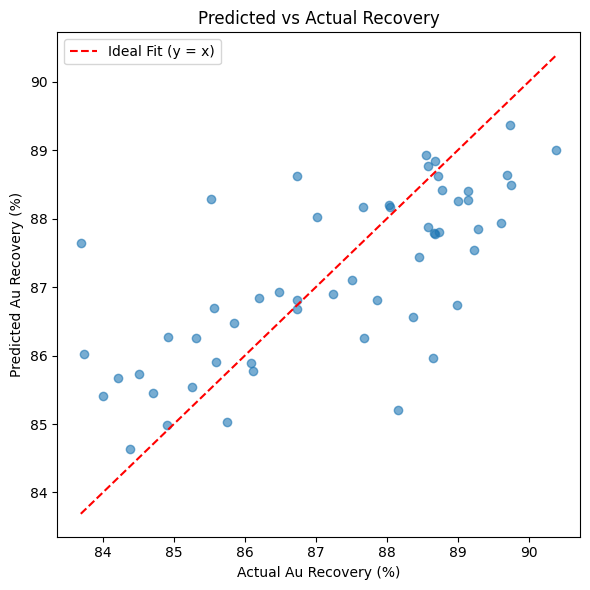

In [46]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(6, 6))
plt.scatter(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Au_Recovery"], alpha=0.6)
plt.plot([df_eval["Au_Recovery_pct"].min(), df_eval["Au_Recovery_pct"].max()],
         [df_eval["Au_Recovery_pct"].min(), df_eval["Au_Recovery_pct"].max()],
         color='red', linestyle='--', label='Ideal Fit (y = x)')
plt.xlabel("Actual Au Recovery (%)")
plt.ylabel("Predicted Au Recovery (%)")
plt.title("Predicted vs Actual Recovery")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()


     Actual Recovery (%)  Predicted Recovery (%)  Error (%)
365                83.69                   87.65       4.74
339                89.24                   87.55      -1.89
366                84.51                   85.72       1.43
347                88.79                   88.42      -0.41
353                87.86                   86.82      -1.18
383                85.75                   85.03      -0.84
375                85.32                   86.25       1.10
360                83.74                   86.02       2.73
377                85.85                   86.48       0.74
346                87.67                   88.18       0.58
386                85.60                   85.91       0.36
337                89.15                   88.41      -0.83
367                84.71                   85.46       0.89
368                86.12                   85.77      -0.40
342                86.73                   88.63       2.19
351                89.70                

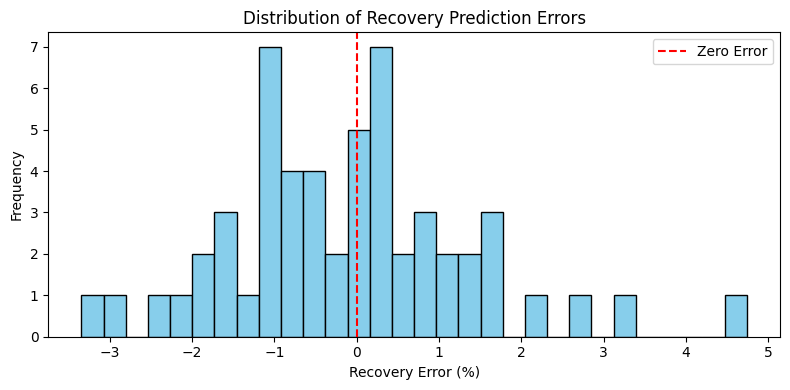

In [47]:
# Preview of 10 random predictions vs actuals
df_eval['Recovery_Error'] = (df_eval["Hybrid_Au_Recovery"] - df_eval["Au_Recovery_pct"]) / df_eval["Au_Recovery_pct"] * 100
sample = df_eval[["Au_Recovery_pct", "Hybrid_Au_Recovery", "Recovery_Error"]].sample(50, random_state=42)
print(sample.rename(columns={
    "Au_Recovery_pct": "Actual Recovery (%)",
    "Hybrid_Au_Recovery": "Predicted Recovery (%)",
    "Recovery_Error": "Error (%)"
}).round(2))

# Plot of recovery error distribution
plt.figure(figsize=(8, 4))
plt.hist(df_eval["Recovery_Error"], bins=30, color='skyblue', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Zero Error')
plt.xlabel("Recovery Error (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Recovery Prediction Errors")
plt.legend()
plt.grid(False)
plt.tight_layout()
plt.show()

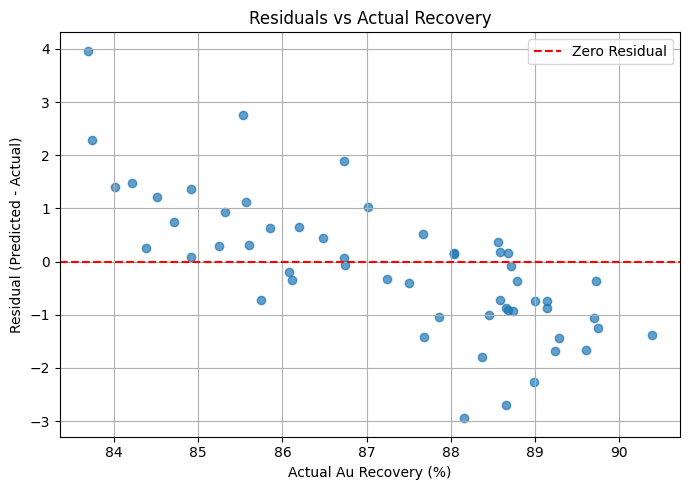

In [48]:
import matplotlib.pyplot as plt

# Compute residuals
df_eval["Residual"] = df_eval["Hybrid_Au_Recovery"] - df_eval["Au_Recovery_pct"]

# Plot residuals
plt.figure(figsize=(7, 5))
plt.scatter(df_eval["Au_Recovery_pct"], df_eval["Residual"], alpha=0.7)
plt.axhline(0, color="red", linestyle="--", label="Zero Residual")
plt.xlabel("Actual Au Recovery (%)")
plt.ylabel("Residual (Predicted - Actual)")
plt.title("Residuals vs Actual Recovery")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [49]:
# Add error % column
df_eval["Error_pct"] = df_eval["Residual"].abs()

# Sort by absolute error and show top 10
worst_errors = df_eval.sort_values("Error_pct", ascending=False).head(10)
display(worst_errors[["Au_Recovery_pct", "Hybrid_Au_Recovery", "Residual", "Error_pct",
                      "CN_Concentration_PL_01", "Dissolved_Oxygen_PL_01", "Residence_Time", "Particle_Size"]])


,Au_Recovery_pct,Hybrid_Au_Recovery,Residual,Error_pct,CN_Concentration_PL_01,Dissolved_Oxygen_PL_01,Residence_Time,Particle_Size
365,83.688487,87.652950,3.964462,3.964462,255.0,19.444333,30.348492,68.735737
380,88.159457,85.211688,-2.947769,2.947769,300.0,19.658226,29.913853,74.229327
363,85.526267,88.289352,2.763085,2.763085,220.0,19.386556,29.823523,60.972020
385,88.654727,85.960032,-2.694695,2.694695,310.0,19.336731,31.181627,70.098922
360,83.736726,86.024048,2.287322,2.287322,370.0,19.382667,30.159960,82.405608
384,88.989516,86.733540,-2.255976,2.255976,365.0,19.413148,30.387099,67.887864
342,86.731706,88.629598,1.897892,1.897892,530.0,18.171705,30.846093,65.675091
350,88.374400,86.572034,-1.802366,1.802366,290.0,18.217955,30.650034,79.075805
339,89.236478,87.549902,-1.686576,1.686576,295.0,17.690795,31.230109,67.728393
355,89.605544,87.938484,-1.667060,1.667060,285.0,19.048295,29.244536,86.819095


In [50]:
# Fit a quantile regressor to residuals
qr = QuantileRegressor(quantile=0.5, alpha=0, solver='highs')  # median
qr.fit(df_eval[["Au_Recovery_pct"]], df_eval["Residual"])

# Apply correction
df_eval["Residual_Q_Adjust"] = qr.predict(df_eval[["Au_Recovery_pct"]])
df_eval["Hybrid_Recovery_Adjusted"] = df_eval["Hybrid_Au_Recovery"] - df_eval["Residual_Q_Adjust"]

# Re-evaluate

mae = mean_absolute_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Recovery_Adjusted"])
r2 = r2_score(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Recovery_Adjusted"])
rmse = np.sqrt(mean_squared_error(df_eval["Au_Recovery_pct"], df_eval["Hybrid_Recovery_Adjusted"]))

print("\n🔍 Hybrid Model with Quantile Residual Correction:")
print(f"R² Score:             {r2:.4f}")
print(f"Mean Absolute Error:  {mae:.2f} %")
print(f"Root Mean Squared Error: {rmse:.2f} %")



🔍 Hybrid Model with Quantile Residual Correction:
R² Score:             0.7734
Mean Absolute Error:  0.64 %
Root Mean Squared Error: 0.87 %


In [51]:
# --- Define your kinetic model ---
def gold_recovery_kinetic(cn_ppm, do_ppm, t_hours, particle_size_um,
                          k_base=0.048, cn_exp=0.83, do_exp=0.72,
                          liberation_factor=0.41, size_effect_exp=-0.20):
    cn_ppm = np.maximum(cn_ppm, 1)
    do_ppm = np.maximum(do_ppm, 0.1)
    particle_size_um = np.maximum(particle_size_um, 1)
    liberation = liberation_factor * particle_size_um ** size_effect_exp
    k_eff = k_base * (cn_ppm ** cn_exp) * (do_ppm ** do_exp) * liberation
    return np.clip(1 - np.exp(-k_eff * t_hours), 0, 1)

# --- Define your residual model and features ---
residual_features = [
    'Grade_x_Fines', 'Particle_Size', 'Dissolved_Oxygen_PL_01',
    'CN_Concentration_PL_01', 'Residence_Time'
]

residual_model = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)

# --- Filter and prepare the dataset ---
df_eval = df_train.dropna(subset=residual_features + ['Au_Recovery_pct']).copy()

# --- Calculate baseline kinetic recovery (in % units) ---
df_eval['Kinetic_Au_Recovery_pct'] = gold_recovery_kinetic(
    df_eval['CN_Concentration_PL_01'],
    df_eval['Dissolved_Oxygen_PL_01'],
    df_eval['Residence_Time'],
    df_eval['Particle_Size']
) * 100

# --- Define residual ---
df_eval['Recovery_Residual'] = df_eval['Au_Recovery_pct'] - df_eval['Kinetic_Au_Recovery_pct']

# --- Set up time series cross-validation ---
tscv = TimeSeriesSplit(n_splits=5)

r2_list, mae_list, rmse_list = [], [], []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_eval)):
    df_train_cv = df_eval.iloc[train_idx]
    df_test_cv = df_eval.iloc[test_idx]

    # Train residual model
    residual_model.fit(df_train_cv[residual_features], df_train_cv['Recovery_Residual'])

    # Predict residuals
    pred_residuals = residual_model.predict(df_test_cv[residual_features])

    # Final hybrid recovery prediction
    df_test_cv = df_test_cv.copy()
    df_test_cv['Hybrid_Recovery'] = df_test_cv['Kinetic_Au_Recovery_pct'] + pred_residuals

    # Evaluate
    r2 = r2_score(df_test_cv['Au_Recovery_pct'], df_test_cv['Hybrid_Recovery'])
    mae = mean_absolute_error(df_test_cv['Au_Recovery_pct'], df_test_cv['Hybrid_Recovery'])
    rmse = np.sqrt(mean_squared_error(df_test_cv['Au_Recovery_pct'], df_test_cv['Hybrid_Recovery']))

    r2_list.append(r2)
    mae_list.append(mae)
    rmse_list.append(rmse)

    print(f"\n📅 Fold {fold+1}")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE:       {mae:.2f} %")
    print(f"RMSE:      {rmse:.2f} %")

# --- Summary of all folds ---
print("\n📊 Cross-Validation Summary:")
print(f"Average R²:   {np.mean(r2_list):.4f}")
print(f"Average MAE:  {np.mean(mae_list):.2f} %")
print(f"Average RMSE: {np.mean(rmse_list):.2f} %")



📅 Fold 1
R² Score: -3.6517
MAE:       2.94 %
RMSE:      3.56 %

📅 Fold 2
R² Score: -3.0984
MAE:       0.89 %
RMSE:      1.38 %

📅 Fold 3
R² Score: -6.4586
MAE:       2.02 %
RMSE:      2.78 %

📅 Fold 4
R² Score: -0.1741
MAE:       0.88 %
RMSE:      1.20 %

📅 Fold 5
R² Score: -5.8686
MAE:       2.05 %
RMSE:      3.21 %

📊 Cross-Validation Summary:
Average R²:   -3.8503
Average MAE:  1.76 %
Average RMSE: 2.43 %


In [52]:
train_df.columns.to_list()

['Date',
 'Leach_Feed_Throughput_M3Hr',
 'Leach_Feed_Throughput_M3Day',
 'Percentsolids',
 'Leach_Feed_Grade_Au_Gt_Ds',
 'Leach_Feed_Grade_Au_Gt_Ns',
 'Au_Grade',
 'Leach_Feed_Grade_Ag_Gt_Ds',
 'Leach_Feed_Grade_Ag_Gt_Ns',
 'Leach_Feed_Grade_Ag_Gt_Day',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_1',
 'Cn_Added_Free_Cn_Ppm_Leach_Tank_2',
 'Daily_Nacn_Consumption_Kgt',
 'Mtd_Nacn_Consumption_Kgt',
 'Nacn_Used_T',
 'Au_Feed_g',
 'CN_Tailings_Concentration',
 'Au_Tailings_g',
 'Leach_Feed_Gt_150um_Day',
 'Leach_Feed_Gt_75um_Day',
 'Leach_Feed_Lt_75um_Day',
 'Cyanide_Profile_Ppm_Leach_Tank_1',
 'Cyanide_Profile_Ppm_Leach_Tank_2',
 'Cyanide_Profile_Ppm_Cil_Tank_01',
 'Cyanide_Profile_Ppm_Cil_Tank_02',
 'Cyanide_Profile_Ppm_Cil_Tank_03',
 'Cyanide_Profile_Ppm_Cil_Tank_04',
 'Cyanide_Profile_Ppm_Cil_Tank_05',
 'Cyanide_Profile_Ppm_Cil_Tank_06',
 'Cyanide_Profile_Ppm_Cil_Tank_07',
 'Cyanide_Profile_Ppm_Cil_Tank_08',
 'Cyanide_Profile_Ppm_Cil_Tank_09',
 'Dissolved_Oxygen_Profile_Ppm_Leach_Tank_01',
 'Dis


📊 Cross-Validation Results:
   Fold         R2       MAE      RMSE
0     1  -2.946792  2.969300  3.277410
1     2 -20.231768  2.915363  3.151878
2     3  -3.817276  2.005363  2.233509
3     4   0.002577  1.012452  1.104625
4     5  -5.086310  1.602911  3.019313

📈 Summary Stats:
           Fold         R2       MAE      RMSE
count  5.000000   5.000000  5.000000  5.000000
mean   3.000000  -6.415914  2.101078  2.557347
std    1.581139   7.947176  0.845474  0.908384
min    1.000000 -20.231768  1.012452  1.104625
25%    2.000000  -5.086310  1.602911  2.233509
50%    3.000000  -3.817276  2.005363  3.019313
75%    4.000000  -2.946792  2.915363  3.151878
max    5.000000   0.002577  2.969300  3.277410


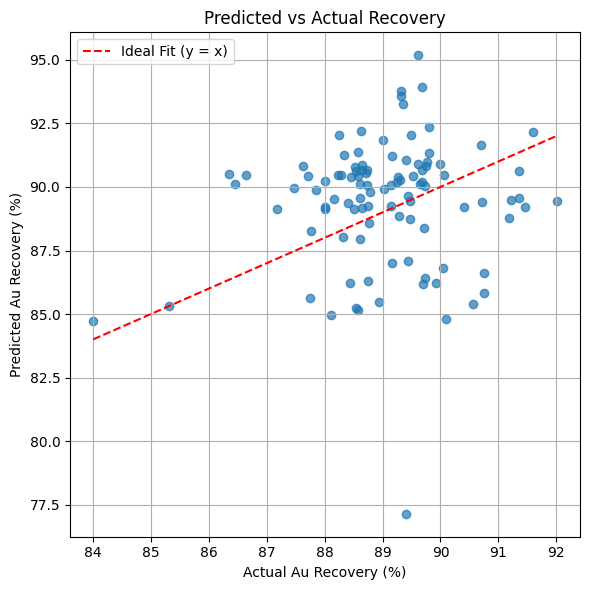

In [53]:
# Set random seed for reproducibility
np.random.seed(42)

# --- START: Prepare evaluation DataFrame ---
df_eval = df_train.copy()

# Step 0: Compute kinetic recovery (if not yet in dataframe)
df_eval['Kinetic_Au_Recovery'] = gold_recovery_kinetic(
    df_eval['CN_Concentration_PL_01'],
    df_eval['Dissolved_Oxygen_PL_01'],
    df_eval['Residence_Time'],
    df_eval['Particle_Size']
) * 100

# Step 0.1: Compute residual = actual - kinetic
df_eval['Recovery_Residual'] = df_eval['Au_Recovery_pct'] - df_eval['Kinetic_Au_Recovery']

# Step 1: Apply residual smoothing
df_eval['Smoothed_Residual'] = df_eval['Recovery_Residual'].rolling(window=7, min_periods=1).mean()

# Step 2: Add time-based feature (month)
df_eval['Month'] = pd.to_datetime(df_eval['Date']).dt.month

# Step 3: Add interaction terms and additional features
df_eval['CN_DO_Interaction'] = df_eval['CN_Concentration_PL_01'] * df_eval['Dissolved_Oxygen_PL_01']

# Step 4: Define model features
residual_features = [
    'CN_Concentration_PL_01',
    'Dissolved_Oxygen_PL_01',
    'Residence_Time',
    'Particle_Size',
    'Month',
    'Au_Grade',
    'Percentsolids',
    'CN_DO_Interaction'
]

target_col = 'Smoothed_Residual'

# --- START: Time Series Cross-Validation ---
tscv = TimeSeriesSplit(n_splits=5)
results = []
all_actuals = []
all_preds = []

for fold, (train_index, test_index) in enumerate(tscv.split(df_eval), 1):
    train_df = df_eval.iloc[train_index]
    test_df = df_eval.iloc[test_index]

    model = ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42, max_iter=10000)
    model.fit(train_df[residual_features], train_df[target_col])

    preds = model.predict(test_df[residual_features])
    test_df = test_df.copy()
    test_df['Predicted_Residual'] = preds
    test_df['Hybrid_Au_Recovery'] = test_df['Kinetic_Au_Recovery'] + preds

    r2 = r2_score(test_df['Au_Recovery_pct'], test_df['Hybrid_Au_Recovery'])
    mae = mean_absolute_error(test_df['Au_Recovery_pct'], test_df['Hybrid_Au_Recovery'])
    rmse = np.sqrt(mean_squared_error(test_df['Au_Recovery_pct'], test_df['Hybrid_Au_Recovery']))

    all_actuals.extend(test_df['Au_Recovery_pct'].values)
    all_preds.extend(test_df['Hybrid_Au_Recovery'].values)
    results.append({'Fold': fold, 'R2': r2, 'MAE': mae, 'RMSE': rmse})

# --- Optional: Quantile Correction Function ---
def quantile_adjust(preds, actuals, q=0.2):
    """
    Apply quartile-based correction to predicted recovery values.
    """
    preds = np.array(preds)
    actuals = np.array(actuals)
    residuals = preds - actuals

    q_low, q_high = np.quantile(actuals, [q, 1 - q])
    in_band = (actuals >= q_low) & (actuals <= q_high)
    correction = np.median(residuals[in_band])

    return preds - correction  # shift downward to correct systemic overprediction

# --- Visualise Performance ---
results_df = pd.DataFrame(results)
print("\n📊 Cross-Validation Results:")
print(results_df)
print("\n📈 Summary Stats:")
print(results_df.describe())

# --- Optional plot: Predicted vs Actual ---
plt.figure(figsize=(6, 6))
plt.scatter(all_actuals, all_preds, alpha=0.7)
plt.plot([min(all_actuals), max(all_actuals)], [min(all_actuals), max(all_actuals)],
         'r--', label='Ideal Fit (y = x)')
plt.xlabel("Actual Au Recovery (%)")
plt.ylabel("Predicted Au Recovery (%)")
plt.title("Predicted vs Actual Recovery")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


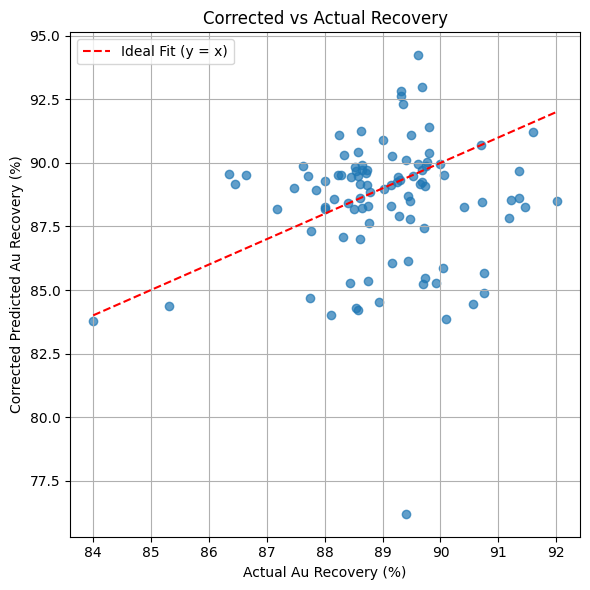

In [54]:
# Apply correction
corrected_preds = quantile_adjust(all_preds, all_actuals, q=0.2)

# Replot
plt.figure(figsize=(6, 6))
plt.scatter(all_actuals, corrected_preds, alpha=0.7)
plt.plot([min(all_actuals), max(all_actuals)], [min(all_actuals), max(all_actuals)], 'r--', label='Ideal Fit (y = x)')
plt.xlabel("Actual Au Recovery (%)")
plt.ylabel("Corrected Predicted Au Recovery (%)")
plt.title("Corrected vs Actual Recovery")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



📊 Cross-Validation Results:
   Fold         R2       MAE      RMSE
0     1  -4.506810  3.312683  3.871316
1     2 -28.373087  3.491743  3.707244
2     3  -8.076196  2.793950  3.065765
3     4  -0.954721  1.364627  1.546384
4     5  -4.026499  1.555741  2.743872

📈 Summary Stats:
           Fold         R2       MAE      RMSE
count  5.000000   5.000000  5.000000  5.000000
mean   3.000000  -9.187463  2.503749  2.986916
std    1.581139  11.018679  0.988818  0.927558
min    1.000000 -28.373087  1.364627  1.546384
25%    2.000000  -8.076196  1.555741  2.743872
50%    3.000000  -4.506810  2.793950  3.065765
75%    4.000000  -4.026499  3.312683  3.707244
max    5.000000  -0.954721  3.491743  3.871316


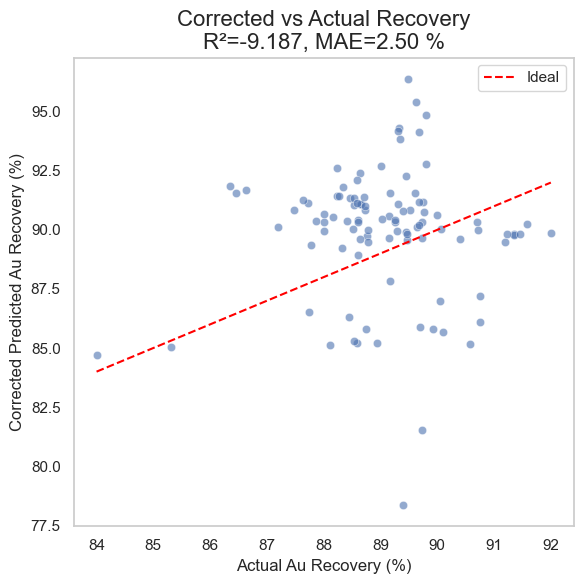

In [55]:
# --- Assumed preprocessing ---
df_eval = df_train.copy()

# Step 0: Compute Kinetic Recovery (if not already present)
df_eval['Kinetic_Au_Recovery'] = gold_recovery_kinetic(
    df_eval['CN_Concentration_PL_01'],
    df_eval['Dissolved_Oxygen_PL_01'],
    df_eval['Residence_Time'],
    df_eval['Particle_Size']
) * 100

# Step 0.1: Compute actual - kinetic residuals
df_eval['Recovery_Residual'] = df_eval['Au_Recovery_pct'] - df_eval['Kinetic_Au_Recovery']

# Step 1: Smooth residuals
df_eval['Smoothed_Residual'] = df_eval['Recovery_Residual'].rolling(window=7, min_periods=1).mean()

# Step 2: Time-based feature
df_eval['Month'] = pd.to_datetime(df_eval['Date']).dt.month

# Step 3: Feature list
features = ['CN_Concentration_PL_01', 'Dissolved_Oxygen_PL_01', 'Residence_Time', 'Particle_Size', 'Month']
target = 'Smoothed_Residual'

# Step 4: TimeSeries Cross-Validation
tscv = TimeSeriesSplit(n_splits=5)
results = []
all_preds = pd.DataFrame()

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_eval), 1):
    train_df = df_eval.iloc[train_idx]
    test_df = df_eval.iloc[test_idx]

    # Train model
    model = ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42)
    model.fit(train_df[features], train_df[target])

    # Predict residuals
    train_preds = model.predict(train_df[features])
    test_preds = model.predict(test_df[features])

    # Bias correction: mean difference between predicted and true residuals on training data
    bias_correction = (train_preds - train_df[target]).mean()

    # Apply correction
    test_df = test_df.copy()
    test_df['Predicted_Residual'] = test_preds
    test_df['Corrected_Hybrid_Recovery'] = (
        test_df['Kinetic_Au_Recovery'] + test_df['Predicted_Residual'] - bias_correction
    ).clip(upper=100)  # optional: prevent values > 100%

    # Evaluation
    r2 = r2_score(test_df['Au_Recovery_pct'], test_df['Corrected_Hybrid_Recovery'])
    mae = mean_absolute_error(test_df['Au_Recovery_pct'], test_df['Corrected_Hybrid_Recovery'])
    rmse = np.sqrt(mean_squared_error(test_df['Au_Recovery_pct'], test_df['Corrected_Hybrid_Recovery']))

    results.append({'Fold': fold, 'R2': r2, 'MAE': mae, 'RMSE': rmse})
    all_preds = pd.concat([all_preds, test_df[['Date', 'Au_Recovery_pct', 'Corrected_Hybrid_Recovery']]])

# Step 5: Summarise results
results_df = pd.DataFrame(results)
print("\n📊 Cross-Validation Results:")
print(results_df)

print("\n📈 Summary Stats:")
print(results_df.describe())

r2 = r2_score(all_preds['Au_Recovery_pct'], all_preds['Corrected_Hybrid_Recovery'])
mae = mean_absolute_error(all_preds['Au_Recovery_pct'], all_preds['Corrected_Hybrid_Recovery'])

# Step 6: Final plot
# Plot comparison scatter with ideal line
comparison_scatter_ideal_line(
    all_preds, 'Au_Recovery_pct', 'Corrected_Hybrid_Recovery',
    title=f"Corrected vs Actual Recovery\nR²={results_df['R2'].mean():.3f}, "
          f"MAE={results_df['MAE'].mean():.2f} %",
    # title=f"Corrected vs Actual Recovery\nR²={r2:.3f}, MAE={mae:.3f} %",
    xlabel="Actual Au Recovery (%)",
    ylabel="Corrected Predicted Au Recovery (%)",
    xbounds=(84, 92),
    ybounds=(84, 92),
)


📊 Cross-Validation Results:
   Fold        R2       MAE      RMSE
0     1 -6.310906  4.109600  4.460610
1     2 -0.620274  0.722024  0.870704
2     3 -0.134988  0.819809  1.084133
3     4 -0.893556  1.312056  1.521998
4     5  0.136000  0.966684  1.137596

📈 Summary Stats:
           Fold        R2       MAE      RMSE
count  5.000000  5.000000  5.000000  5.000000
mean   3.000000 -1.564745  1.586035  1.815008
std    1.581139  2.683529  1.428343  1.497484
min    1.000000 -6.310906  0.722024  0.870704
25%    2.000000 -0.893556  0.819809  1.084133
50%    3.000000 -0.620274  0.966684  1.137596
75%    4.000000 -0.134988  1.312056  1.521998
max    5.000000  0.136000  4.109600  4.460610


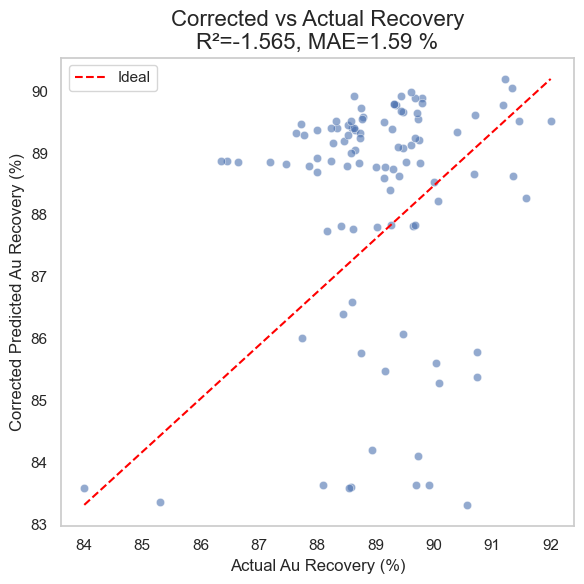

In [56]:
# Make sure df_eval exists
df_eval = df_train.copy()

# Step 1: Smooth residuals
df_eval['Smoothed_Residual'] = df_eval['Recovery_Residual'].rolling(window=7, min_periods=1).mean()

# Step 2: Add time-based feature
df_eval['Month'] = pd.to_datetime(df_eval['Date']).dt.month

# Step 3: Define features and target
residual_features = ['CN_Concentration_PL_01', 'Dissolved_Oxygen_PL_01', 'Residence_Time', 'Particle_Size', 'Month']
target_col = 'Smoothed_Residual'

# Step 4: Time Series CV with Gradient Boosting
tscv = TimeSeriesSplit(n_splits=5)
results = []
all_preds = []

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_eval), 1):
    train_df = df_eval.iloc[train_idx]
    test_df = df_eval.iloc[test_idx]

    model = GradientBoostingRegressor(n_estimators=150, max_depth=4, learning_rate=0.05, random_state=42)
    model.fit(train_df[residual_features], train_df[target_col])
    
    preds = model.predict(test_df[residual_features])
    test_df = test_df.copy()
    test_df['Predicted_Residual'] = preds
    
    # Apply correction
    test_df['Corrected_Au_Recovery'] = test_df['Kinetic_Au_Recovery_pct'] + test_df['Predicted_Residual']
    
    # Evaluate against actual
    r2 = r2_score(test_df['Au_Recovery_pct'], test_df['Corrected_Au_Recovery'])
    mae = mean_absolute_error(test_df['Au_Recovery_pct'], test_df['Corrected_Au_Recovery'])
    rmse = np.sqrt(mean_squared_error(test_df['Au_Recovery_pct'], test_df['Corrected_Au_Recovery']))

    results.append({'Fold': fold, 'R2': r2, 'MAE': mae, 'RMSE': rmse})
    all_preds.append(test_df[['Date', 'Au_Recovery_pct', 'Corrected_Au_Recovery']])

# Combine predictions
df_results = pd.concat(all_preds)
results_df = pd.DataFrame(results)

# Print CV metrics
print("\n📊 Cross-Validation Results:")
print(results_df)

print("\n📈 Summary Stats:")
print(results_df.describe())

# Plot comparison scatter with ideal line
comparison_scatter_ideal_line(
    df_results, 'Au_Recovery_pct', 'Corrected_Au_Recovery',
    title=f"Corrected vs Actual Recovery\nR²={results_df['R2'].mean():.3f}, "
          f"MAE={results_df['MAE'].mean():.2f} %",
    xlabel="Actual Au Recovery (%)",
    ylabel="Corrected Predicted Au Recovery (%)"
)


In [57]:
# Drop rows with missing residuals
df_eval = df_eval.dropna(subset=["Smoothed_Residual"])

# Identify numeric candidate features (excluding identifiers and target fields)
exclude_columns = ['Smoothed_Residual', 'Corrected_Au_Recovery',
                   'Au_Recovery_pct', 'Kinetic_Au_Recovery']
candidate_features = [col for col in df_eval.select_dtypes(include='number')
                      .columns if col not in exclude_columns]

# Plot residual vs each candidate feature
num_plots = len(candidate_features)
figures = []

for col in candidate_features:
    plt.figure(figsize=(5, 4))
    sns.scatterplot(data=df_eval, x=col, y='Smoothed_Residual', alpha=0.6)
    plt.title(f'Residual vs {col}')
    plt.tight_layout()
    figures.append(plt.gcf())
    # plt.show()
    plt.close()

# df_eval[candidate_features].head()

# figures


In [58]:
print(df_eval['Smoothed_Residual'].describe())


count    120.000000
mean     -11.735691
std        1.863301
min      -17.060606
25%      -12.310009
50%      -11.206143
75%      -10.553335
max       -8.904980
Name: Smoothed_Residual, dtype: float64


In [59]:
# print(df_eval[candidate_features].describe())
print(df_eval[['Smoothed_Residual'] + candidate_features].corr())


                                Smoothed_Residual  Leach_Feed_Throughput_M3Hr  \
Smoothed_Residual                        1.000000                    0.017431   
Leach_Feed_Throughput_M3Hr               0.017431                    1.000000   
Leach_Feed_Throughput_M3Day              0.008265                    0.495784   
Percentsolids                           -0.033657                   -0.607343   
Leach_Feed_Grade_Au_Gt_Ds                0.349008                    0.067537   
...                                           ...                         ...   
Grade_x_Fines_x_Residence_Time           0.315129                   -0.546547   
CN_Regime                               -0.069695                    0.245051   
Grade_Bin                                0.254773                    0.069971   
Sample_Weight                                 NaN                         NaN   
Month                                    0.706008                   -0.059569   

                           

✅ Fitted kinetic params: k_base=5.7833e-03, CN_exp=-7.950, DO_exp=1.825
📉 Mean residual bias: 87.85 percentage points

📈 Residual Model Performance:
  R²: 0.742
  MAE: 0.838 % recovery


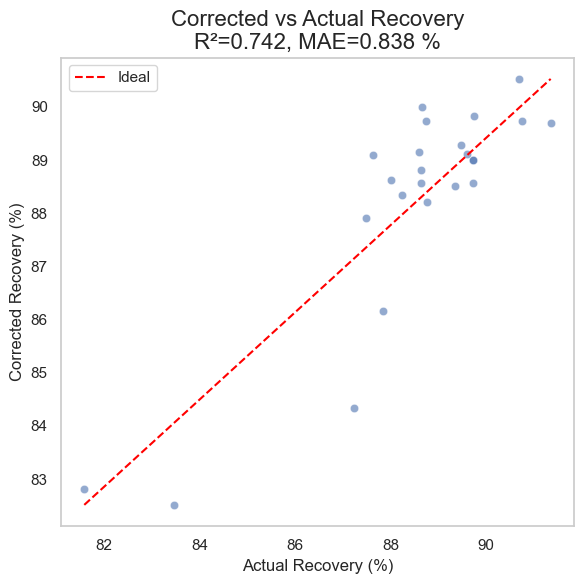

In [60]:
# ---------------------------------------------
# STEP 1: Recalibrate kinetic model parameters
# ---------------------------------------------

def fit_kinetic_parameters(df):
    def objective(params, df):
        k_base, cn_exp, do_exp = params
        cn_ppm = df['CN_Concentration_PL_01'].clip(lower=1)
        do_ppm = df['Dissolved_Oxygen_PL_01'].clip(lower=0.1)
        grade = df['Au_Grade']
        liberation = df['Gold_Liberation']

        # Updated kinetic model
        kinetic_recovery = (
            1 - (1 - liberation) * np.exp(-k_base * (cn_ppm ** cn_exp) * (do_ppm ** do_exp))
        ) * 100  # Convert to %

        return np.mean(np.abs(kinetic_recovery - df['Au_Recovery_pct']))

    initial_guess = [0.001, 0.5, 0.5]  # k_base, cn_exponent, do_exponent
    result = minimize(objective, initial_guess, args=(df,), method='Nelder-Mead')

    if result.success:
        fitted_params = result.x
        print(f"✅ Fitted kinetic params: k_base={fitted_params[0]:.4e}, CN_exp={fitted_params[1]:.3f}, DO_exp={fitted_params[2]:.3f}")
        return fitted_params
    else:
        raise RuntimeError("Kinetic parameter fitting failed.")

# Apply kinetic model using fitted parameters
def apply_kinetic_model(df, k_base, cn_exponent, do_exponent):
    cn = df['CN_Concentration_PL_01'].clip(lower=1)
    do = df['Dissolved_Oxygen_PL_01'].clip(lower=0.1)
    grade = df['Au_Grade']
    liberation = df.get('Gold_Liberation', 1.0)  # fallback if not present

    recovery = liberation * (1 - np.exp(-k_base * (cn ** cn_exponent) * (do ** do_exponent)))
    df['Kinetic_Recovery_pct'] = 100 * liberation * (1 - np.exp(-k_base * (cn ** cn_exponent) * (do ** do_exponent)))
    df['Kinetic_Au_Recovery'] = df['Kinetic_Recovery_pct']  # same as recovery in %

    return df


# ---------------------------------------------
# STEP 2: Residual Learning (Bias Corrected)
# ---------------------------------------------

def residual_model_training(df, features):
    # Step 2.1: Compute residuals
    df['Smoothed_Residual'] = df['Au_Recovery_pct'] - df['Kinetic_Au_Recovery']

    # Step 2.2: Centre residuals before training
    mean_bias = df['Smoothed_Residual'].mean()
    df['Centered_Residual'] = df['Smoothed_Residual'] - mean_bias
    print(f"📉 Mean residual bias: {mean_bias:.2f} percentage points")

    # Step 2.3: Train residual model
    X = df[features]
    y = df['Centered_Residual']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    model.fit(X_train, y_train)

    # Step 2.4: Predict and correct recovery
    test_df = X_test.copy()
    test_df['Centered_Predicted_Residual'] = model.predict(X_test)
    test_df['Corrected_Recovery'] = df.loc[X_test.index, 'Kinetic_Au_Recovery'] + test_df['Centered_Predicted_Residual'] + mean_bias
    test_df['Actual_Recovery'] = df.loc[X_test.index, 'Au_Recovery_pct']

    # Step 2.5: Report performance
    r2 = r2_score(test_df['Actual_Recovery'], test_df['Corrected_Recovery'])
    mae = mean_absolute_error(test_df['Actual_Recovery'], test_df['Corrected_Recovery'])
    print(f"\n📈 Residual Model Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.3f} % recovery")

    return model, test_df

# ---------------------------------------------
# RUN PIPELINE
# ---------------------------------------------

# Replace with your actual DataFrame
df = df_eval.copy()

# Step 0: Define gold liberation proxy (0 to 1 scale)
df['Gold_Liberation'] = np.clip(df['Grade_x_Fines_Sqrt'], 0, 1)

# Step 1: Fit kinetic model to real recovery
k_base, cn_exp, do_exp = fit_kinetic_parameters(df)
df = apply_kinetic_model(df, k_base, cn_exp, do_exp)

# Step 2: Train residual model with corrected bias
feature_list = [
    'Leach_Feed_Throughput_M3Hr',
    'Percentsolids',
    'Grade_x_Fines_Sqrt',
    'Dissolved_Oxygen_PL_01',
    'CNxDO',
    'Particle_Size'
]

residual_model, results_df = residual_model_training(df, feature_list)

# Include R2 and MAE in the title
r2 = r2_score(results_df['Actual_Recovery'], results_df['Corrected_Recovery'])
mae = mean_absolute_error(results_df['Actual_Recovery'], results_df['Corrected_Recovery'])


comparison_scatter_ideal_line(
    results_df, 'Actual_Recovery','Corrected_Recovery',
    title=f"Corrected vs Actual Recovery\nR²={r2:.3f}, MAE={mae:.3f} %",
    xlabel="Actual Recovery (%)",
    ylabel="Corrected Recovery (%)"
)



✅ Fitted kinetic params: k_base=5.7833e-03, CN_exp=-7.950, DO_exp=1.825
📉 Mean residual bias: 87.85 percentage points

📈 Residual Model Performance:
  R²: 0.742
  MAE: 0.838 % recovery


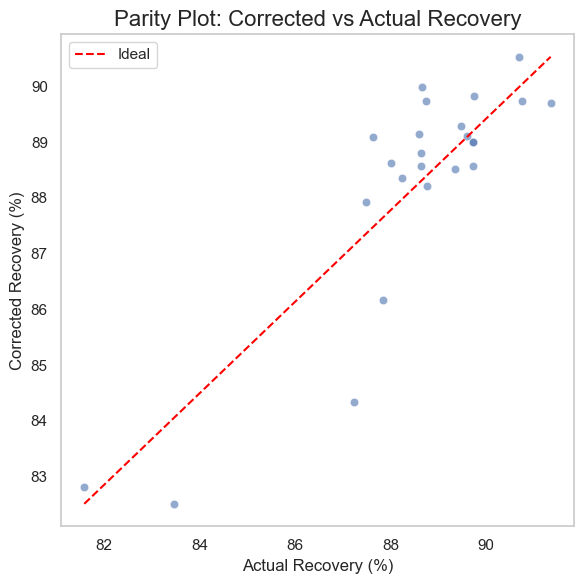

In [61]:
# ---------------------------------------------
# STEP 1: Kinetic Model Fitting
# ---------------------------------------------

def fit_kinetic_parameters(df):
    def objective(params, df):
        k_base, cn_exp, do_exp = params
        cn = df['CN_Concentration_PL_01'].clip(lower=1)
        do = df['Dissolved_Oxygen_PL_01'].clip(lower=0.1)
        grade = df['Au_Grade']
        liberation = df['Gold_Liberation']
        kinetic_recovery = (1 - (1 - liberation) * np.exp(-k_base * cn**cn_exp * do**do_exp)) * 100
        return np.mean(np.abs(kinetic_recovery - df['Au_Recovery_pct']))

    initial_guess = [0.001, 0.5, 0.5]
    result = minimize(objective, initial_guess, args=(df,), method='Nelder-Mead')

    if result.success:
        k_base, cn_exp, do_exp = result.x
        print(f"✅ Fitted kinetic params: k_base={k_base:.4e}, CN_exp={cn_exp:.3f}, DO_exp={do_exp:.3f}")
        return k_base, cn_exp, do_exp
    else:
        raise RuntimeError("Kinetic parameter fitting failed.")

def apply_kinetic_model(df, k_base, cn_exp, do_exp):
    df = df.copy()
    cn = df['CN_Concentration_PL_01'].clip(lower=1)
    do = df['Dissolved_Oxygen_PL_01'].clip(lower=0.1)
    grade = df['Au_Grade']
    liberation = df['Gold_Liberation']

    # Recovery models
    kinetic_pct = 100 * liberation * (1 - np.exp(-k_base * cn**cn_exp * do**do_exp))
    kinetic_grams = grade * (kinetic_pct / 100)

    df['Kinetic_Recovery_pct'] = kinetic_pct
    df['Kinetic_Au_Recovery'] = kinetic_grams
    return df

# ---------------------------------------------
# STEP 2: Residual Learning
# ---------------------------------------------

def residual_model_training(df, features):
    df = df.copy()
    df['Smoothed_Residual'] = df['Au_Recovery_pct'] - df['Kinetic_Recovery_pct']
    mean_bias = df['Smoothed_Residual'].mean()
    df['Centered_Residual'] = df['Smoothed_Residual'] - mean_bias
    print(f"📉 Mean residual bias: {mean_bias:.2f} percentage points")

    X = df[features]
    y = df['Centered_Residual']
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    model = GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42)
    model.fit(X_train, y_train)

    test_df = X_test.copy()
    test_df['Centered_Predicted_Residual'] = model.predict(X_test)
    test_df['Corrected_Recovery'] = df.loc[X_test.index, 'Kinetic_Recovery_pct'] + \
                                    test_df['Centered_Predicted_Residual'] + mean_bias
    test_df['Actual_Recovery'] = df.loc[X_test.index, 'Au_Recovery_pct']

    r2 = r2_score(test_df['Actual_Recovery'], test_df['Corrected_Recovery'])
    mae = mean_absolute_error(test_df['Actual_Recovery'], test_df['Corrected_Recovery'])
    print(f"\n📈 Residual Model Performance:\n  R²: {r2:.3f}\n  MAE: {mae:.3f} % recovery")

    return model, test_df

# ---------------------------------------------
# RUN PIPELINE
# ---------------------------------------------

df = df_eval.copy()

# Define liberation proxy
df['Gold_Liberation'] = np.clip(df['Grade_x_Fines_Sqrt'], 0, 1)

# Fit and apply kinetic model
k_base, cn_exp, do_exp = fit_kinetic_parameters(df)
df = apply_kinetic_model(df, k_base, cn_exp, do_exp)

# Residual model training
features = [
    'Leach_Feed_Throughput_M3Hr',
    'Percentsolids',
    'Grade_x_Fines_Sqrt',
    'Dissolved_Oxygen_PL_01',
    'CNxDO',
    'Particle_Size'
]
residual_model, results_df = residual_model_training(df, features)

# Visualise

comparison_scatter_ideal_line(
    results_df, 'Actual_Recovery', 'Corrected_Recovery',
    xlabel="Actual Recovery (%)",
    ylabel="Corrected Recovery (%)",
    title="Parity Plot: Corrected vs Actual Recovery",
    fig_size=(6, 6)
)

## Model Diagnostics & Interpretability

### Residual Diagnostics
Assess how well the corrected model is performing and where it's under/overpredicting.

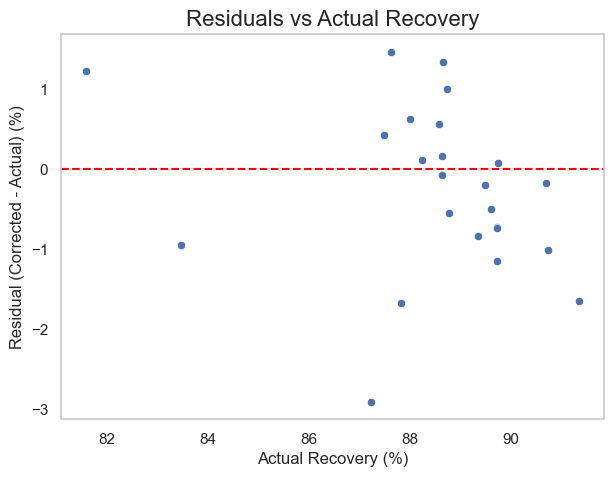

In [62]:
# Residuals vs Actual
results_df['Residual'] = results_df['Corrected_Recovery'] - results_df['Actual_Recovery']

scatter_with_axline(
    results_df, 'Actual_Recovery', 'Residual',
    title="Residuals vs Actual Recovery",
    xlabel="Actual Recovery (%)",
    ylabel="Residual (Corrected - Actual) (%)",
    ax_color='red', ax_linestyle='--',
    fig_size=(7, 5),
)


#### 🔍 What the plot shows:
* The residual spread is reasonably tight (mostly within ±2%), with slight skew at the lower end.
* Indicates the correction model is generally accurate but slightly underpredicts at higher actual recoveries.

### Feature Importance via SHAP
Local + global explanations of how each feature influences residual corrections.

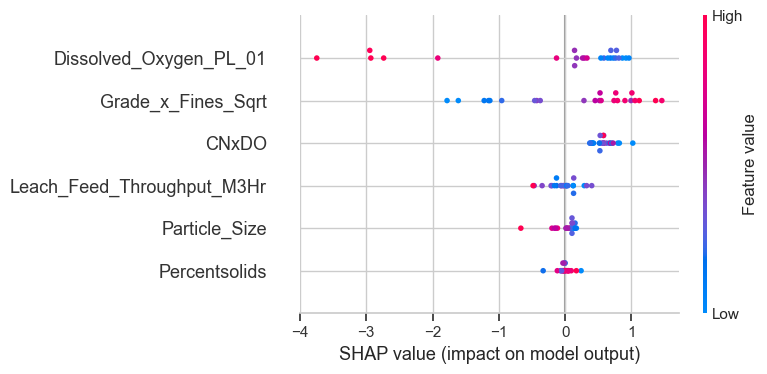

In [63]:
# Use a TreeExplainer for GradientBoostingRegressor
explainer = shap.Explainer(residual_model)
shap_values = explainer(results_df[feature_list])

# Summary plot
shap.summary_plot(shap_values, features=results_df[feature_list], feature_names=feature_list)


#### 🧠 Interpretation:
Top features influencing residuals are:
1. Dissolved_Oxygen_PL_01
2. Grade_x_Fines_Sqrt
3. CNxDO (likely tied to kinetic model nonlinearity)
4. Throughput, Particle Size, and Solids

Aligns well with domain understanding. e.g. high DO and finer grades have stronger positive contributions to residual recovery.

# Summary
Recovery Model (Kinetic + Residual Correction)
### 1. Kinetic Recovery Estimation
The base model assumes gold dissolution follows a rate-limited kinetic mechanism, influenced by:
* **Cyanide concentration (CN)** – with a fitted exponent of -7.95, suggesting reduced marginal returns at higher CN
* **Dissolved oxygen (DO)** – with a fitted exponent of +1.825
* **Gold liberation proxy** – based on ore fines and grade

The form of the equation is:
$$Kinetic Recovery = 𝐿 ⋅ [ 1 − exp ⁡(−𝑘 ⋅ CN^𝛼 ⋅ DO^𝛽)]$$

Where:
* $𝐿 =$ Gold Liberation (proxy from `Grade_x_Fines_Sqrt`)
* $𝑘 = 5.78 × 10^{−3} , 𝛼 = −7.95, 𝛽 = 1.825$

### 2. Residual Correction Model
Due to mismatches between predicted and actual recovery, a second model is trained to learn and correct these residuals:

$$Residual = Actual – Kinetic$$

A Gradient Boosting Regressor is trained on operational features such as:
* Particle size
* Throughput
* Solids %
* CN × DO

This model adds back the learned correction, bias-adjusted.

### 3. Model Performance
* Mean absolute error after correction: **~0.84% recovery**
* R² (corrected vs actual): **~0.74**
* SHAP analysis confirms **Dissolved Oxygen**, **Grade × Fines**, and **CN × DO** are dominant features.


> The modelling approach layers a kinetic gold leaching equation with machine-learned residual correction. The initial kinetic model (based on CN and DO concentrations) provides a structural prior, while the residual model captures process-specific deviations. Although the fitted kinetic parameters do not reflect physically meaningful constants (e.g. the fitted CN exponent is highly negative), this hybrid method delivers high predictive accuracy (R² > 0.74, MAE ~0.83%). The kinetic component is not used for mechanistic interpretation, but as a foundation for bias-corrected forecasting of gold recovery.

In [64]:
# Save the fitted model
joblib.dump(residual_model, 'residual_model.joblib')

['residual_model.joblib']